# ==== Setup, display options, and load ALL sheets ====

In [49]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as st
from IPython.display import display

# Plotting (keep dependencies light; we'll add seaborn later only if needed)
import matplotlib
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Jupyter inline plotting (safe to ignore if not in Jupyter)
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

# ---- Display settings ----
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}" if isinstance(x, float) else str(x))

print(f"matplotlib version: {matplotlib.__version__}")
print(f"pandas version:     {pd.__version__}")

# ---- Point this to your workbook ----
# If you plan to use a different file, just change this path.
PATH_WORKBOOK = Path("MS_Capstone_Final_Quality_Check_Summary.xlsx")

if not PATH_WORKBOOK.exists():
    raise FileNotFoundError(f"Workbook not found at: {PATH_WORKBOOK.resolve()}")

# ---- Load all sheets into a dict of DataFrames ----
xls = pd.ExcelFile(PATH_WORKBOOK)
sheet_names = xls.sheet_names
dfs = {sn: pd.read_excel(PATH_WORKBOOK, sheet_name=sn) for sn in sheet_names}

print("\nLoaded sheets:")
for sn, df_ in dfs.items():
    print(f" - {sn:25s} shape={df_.shape}")

# ---- Light typing: convert any '*date*' columns to datetime (dayfirst for your format) ----
def _coerce_dates_inplace(df: pd.DataFrame) -> None:
    for col in df.columns:
        if "date" in str(col).lower():
            # Convert to datetime but keep values (NaT if invalid); do not alter actual dates.
            df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

for sn in sheet_names:
    _coerce_dates_inplace(dfs[sn])

# ---- Convenience handle for the primary analysis sheet if present ----
df = dfs.get("clean_data")
if df is not None:
    print("\n[clean_data] preview (first 5 rows):")
    display(df.head(5))
    print("\n[clean_data] columns:")
    print(list(df.columns))
else:
    print("\nNo sheet named 'clean_data' found. Use `dfs.keys()` to see available sheets:")
    print(dfs.keys())


matplotlib version: 3.10.5
pandas version:     2.2.2

Loaded sheets:
 - clean_data                shape=(585, 32)
 - qc_flags                  shape=(190, 4)
 - qc_summary                shape=(5, 2)
 - nulls_by_col              shape=(32, 2)
 - summary                   shape=(6, 2)
 - date_parse_failures       shape=(0, 3)

[clean_data] preview (first 5 rows):


,Company,Ticker,AV_Ticker.BSE,Sector,Cap Category,Period,Sales,Expenses,Operating Profit,OPM %,Other Income,Interest,Depreciation,Profit before tax,Tax %,Net Profit,EPS in Rs,Result Date,Revenue,Financing Profit,Financing Margin %,_T_date,Closing Price (T),_T1_date,Closing Price (T+1),_T2_date,Closing Price (T+2),_T3_date,Closing Price (T+3),3-Day Avg Price Post Result,3-Day Return (%),"Movement Label (1,0)"
0,Tata Consultancy Services,TCS,TCS.BSE,IT / Technology,Large,Jun 2022,"52,758.0000","39,342.0000","13,416.0000",25.0000,789.0000,199.0000,"1,230.0000","12,776.0000",25.0000,"9,519.0000",25.9000,2022-07-08,NaN,NaN,NaN,2022-08-07,"3,265.4500",2022-11-07,"3,113.8000",2022-12-07,"3,084.7000",2022-07-13,"3,038.7500","3,079.0833",-5.7100,0.0000
1,Tata Consultancy Services,TCS,TCS.BSE,IT / Technology,Large,Sep 2022,"55,309.0000","40,793.0000","14,516.0000",26.0000,965.0000,148.0000,"1,237.0000","14,096.0000",26.0000,"10,465.0000",28.5100,2022-10-10,NaN,NaN,NaN,2022-10-10,"3,118.5500",2022-11-10,"3,069.5500",2022-12-10,"3,100.7500",2022-10-13,"3,103.3000","3,091.2000",-0.8800,0.0000
2,Tata Consultancy Services,TCS,TCS.BSE,IT / Technology,Large,Dec 2022,"58,229.0000","42,676.0000","15,553.0000",27.0000,520.0000,160.0000,"1,269.0000","14,644.0000",26.0000,"10,883.0000",29.6400,2023-01-09,NaN,NaN,NaN,2023-09-01,"3,319.9500",2023-10-01,"3,286.4000",2023-11-01,"3,328.7000",2023-12-01,"3,334.3500","3,316.4833",-0.1000,0.0000
3,Tata Consultancy Services,TCS,TCS.BSE,IT / Technology,Large,Mar 2023,"59,162.0000","43,388.0000","15,774.0000",27.0000,"1,175.0000",272.0000,"1,286.0000","15,391.0000",26.0000,"11,436.0000",31.1300,2023-04-12,NaN,NaN,NaN,2023-12-04,"3,241.6500",2023-04-13,"3,188.8500",2023-04-17,"3,139.5000",2023-04-18,"3,130.7500","3,153.0333",-2.7300,0.0000
4,Tata Consultancy Services,TCS,TCS.BSE,IT / Technology,Large,Jun 2023,"59,381.0000","44,383.0000","14,998.0000",25.0000,"1,397.0000",163.0000,"1,243.0000","14,989.0000",26.0000,"11,120.0000",30.2600,2023-07-12,NaN,NaN,NaN,2023-12-07,"3,259.9000",2023-07-13,"3,340.5500",2023-07-14,"3,514.6500",2023-07-17,"3,491.7000","3,448.9667",5.8000,1.0000



[clean_data] columns:
['Company', 'Ticker', 'AV_Ticker.BSE', 'Sector', 'Cap Category', 'Period', 'Sales', 'Expenses', 'Operating Profit', 'OPM %', 'Other Income', 'Interest', 'Depreciation', 'Profit before tax', 'Tax %', 'Net Profit', 'EPS in Rs', 'Result Date', 'Revenue', 'Financing Profit', 'Financing Margin %', '_T_date', 'Closing Price (T)', '_T1_date', 'Closing Price (T+1)', '_T2_date', 'Closing Price (T+2)', '_T3_date', 'Closing Price (T+3)', '3-Day Avg Price Post Result', '3-Day Return (%)', 'Movement Label (1,0)']


# ==== Health checks ====

Confirms presence of expected columns and shows shapes/dtypes.

Null counts for key features.

Movement label balance (Up/Down).

Date sanity: counts examples where _T_date is after Result Date (shouldn’t be), and where T→T+3 dates aren’t strictly increasing (gaps for holidays are fine; this only flags reversals/same-day repeats).

Informational range checks for Financing Margin %, Tax %, OPM %.

Summary stats for 3-Day Return (%).

In [38]:
# Work off the already-loaded `df`
assert isinstance(df, pd.DataFrame), "Expected `df` from Cell 1 (clean_data sheet)."

print("Shape:", df.shape)
print("Columns:", list(df.columns))

# ---- Required / expected columns for EDA ----
REQUIRED_COLS = [
    "Company","Ticker","Sector","Cap Category","Period",
    "Result Date","_T_date","_T1_date","_T2_date","_T3_date",
    "Closing Price (T)","Closing Price (T+1)","Closing Price (T+2)","Closing Price (T+3)",
    "EPS in Rs","OPM %","Net Profit","Sales","Revenue","Financing Margin %",
    "3-Day Avg Price Post Result","3-Day Return (%)","Movement Label (1,0)"
]

missing_required = [c for c in REQUIRED_COLS if c not in df.columns]
if missing_required:
    print("\n[WARN] Missing expected columns:", missing_required)
else:
    print("\nAll expected columns are present.")

# ---- Basic counts ----
print("\n--- Snapshot ---")
print("Unique tickers:", df["Ticker"].nunique() if "Ticker" in df else "n/a")
print("Unique sectors:", df["Sector"].nunique() if "Sector" in df else "n/a")
print("Date range (Result Date):",
      (pd.to_datetime(df["Result Date"], errors="coerce").min(),
       pd.to_datetime(df["Result Date"], errors="coerce").max()) if "Result Date" in df else "n/a")

# ---- Nulls (key columns) ----
key_cols = [
    "Result Date","_T_date","_T1_date","_T2_date","_T3_date",
    "Closing Price (T)","Closing Price (T+1)","Closing Price (T+2)","Closing Price (T+3)",
    "3-Day Avg Price Post Result","3-Day Return (%)","Movement Label (1,0)",
    "EPS in Rs","OPM %","Net Profit","Sales","Revenue","Financing Margin %"
]
key_cols = [c for c in key_cols if c in df.columns]
nulls = df[key_cols].isna().sum().sort_values(ascending=False)
print("\n--- Nulls in key columns ---")
display(nulls.to_frame("Nulls").T if len(nulls) > 15 else nulls)

# ---- Dtypes (heads-up) ----
print("\n--- Dtypes ---")
display(df[key_cols].dtypes.to_frame("dtype").T if len(key_cols) > 15 else df[key_cols].dtypes)

# ---- Movement label sanity ----
if "Movement Label (1,0)" in df:
    lbl = df["Movement Label (1,0)"].dropna()
    counts = lbl.value_counts().rename({1: "Up (1)", 0: "Down (0)"})
    print("\n--- Movement label balance ---")
    display(counts.to_frame("count"))
    if not set(lbl.unique()).issubset({0,1}):
        bad_vals = sorted(set(lbl.unique()) - {0,1})
        print("[WARN] Label has non-binary values:", bad_vals)

# ---- Date sanity checks ----
def coerce_date(s):
    return pd.to_datetime(s, errors="coerce", dayfirst=True)

has_dates = all(c in df.columns for c in ["Result Date","_T_date","_T1_date","_T2_date","_T3_date"])
if has_dates:
    dtmp = df.copy()
    dtmp["Result Date_dt"] = coerce_date(dtmp["Result Date"])
    for c in ["_T_date","_T1_date","_T2_date","_T3_date"]:
        dtmp[c+"_dt"] = coerce_date(dtmp[c])

    # Rule: T_date should be on or before Result Date (if T is "exact if traded else prior trade day")
    mask_after = (dtmp["_T_date_dt"].notna() & dtmp["Result Date_dt"].notna()
                  & (dtmp["_T_date_dt"] > dtmp["Result Date_dt"]))
    n_after = int(mask_after.sum())

    # Strictly increasing calendar order across T -> T+3 (allow gaps for weekends/holidays)
    def is_strictly_increasing(row):
        seq = [row["_T_date_dt"], row["_T1_date_dt"], row["_T2_date_dt"], row["_T3_date_dt"]]
        seq = [x for x in seq if pd.notna(x)]
        return all(seq[i] < seq[i+1] for i in range(len(seq)-1)) if len(seq) > 1 else True

    non_mono_idx = []
    for i, r in dtmp.iterrows():
        if not is_strictly_increasing(r):
            non_mono_idx.append(i)

    print("\n--- Date sanity ---")
    print("T_date AFTER Result Date (should be <=):", n_after)
    print("Non-monotonic T..T+3 calendar ordering:", len(non_mono_idx))

    if n_after > 0:
        print("  Sample rows (T_date > Result Date):")
        display(dtmp.loc[mask_after, ["Company","Ticker","Result Date","_T_date"]].head(5))

    if len(non_mono_idx) > 0:
        print("  Sample rows (non-monotonic):")
        display(dtmp.loc[non_mono_idx, ["Company","Ticker","Result Date","_T_date","_T1_date","_T2_date","_T3_date"]].head(5))

# ---- Range sanity for a few financial columns (no edits, just flags) ----
def clip_tuple(v):
    try:
        return (float(np.nanmin(v)), float(np.nanmax(v)))
    except Exception:
        return ("n/a","n/a")

range_checks = []
if "Financing Margin %" in df:
    rng = clip_tuple(df["Financing Margin %"])
    out = df["Financing Margin %"].dropna()
    n_low  = (out < -1.0).sum()   # allow small negatives
    n_high = (out > 15.0).sum()   # typical retail banking spread range ballpark
    range_checks.append(("Financing Margin %", rng, int(n_low+n_high)))

if "Tax %" in df:
    rng = clip_tuple(df["Tax %"])
    out = df["Tax %"].dropna()
    n_low  = (out < 0).sum()
    n_high = (out > 60).sum()
    range_checks.append(("Tax %", rng, int(n_low+n_high)))

if "OPM %" in df:
    rng = clip_tuple(df["OPM %"])
    out = df["OPM %"].dropna()
    n_low  = (out < -10).sum()
    n_high = (out > 80).sum()
    range_checks.append(("OPM %", rng, int(n_low+n_high)))

if range_checks:
    rc_df = pd.DataFrame(range_checks, columns=["Metric","Observed (min,max)","Out-of-range count"])
    print("\n--- Range sanity (informational) ---")
    display(rc_df)

# ---- Return sanity ----
if "3-Day Return (%)" in df:
    ret = pd.to_numeric(df["3-Day Return (%)"], errors="coerce")
    print("\n--- 3-Day Return (%) summary ---")
    display(ret.describe(percentiles=[.05,.25,.5,.75,.95]).to_frame("value").T)
    n_missing_ret = ret.isna().sum()
    print("Missing 3-Day Return (%):", int(n_missing_ret))



Shape: (585, 32)
Columns: ['Company', 'Ticker', 'AV_Ticker.BSE', 'Sector', 'Cap Category', 'Period', 'Sales', 'Expenses', 'Operating Profit', 'OPM %', 'Other Income', 'Interest', 'Depreciation', 'Profit before tax', 'Tax %', 'Net Profit', 'EPS in Rs', 'Result Date', 'Revenue', 'Financing Profit', 'Financing Margin %', '_T_date', 'Closing Price (T)', '_T1_date', 'Closing Price (T+1)', '_T2_date', 'Closing Price (T+2)', '_T3_date', 'Closing Price (T+3)', '3-Day Avg Price Post Result', '3-Day Return (%)', 'Movement Label (1,0)']

All expected columns are present.

--- Snapshot ---
Unique tickers: 45
Unique sectors: 5
Date range (Result Date): (Timestamp('2022-02-16 00:00:00'), Timestamp('2025-08-08 00:00:00'))

--- Nulls in key columns ---


,Financing Margin %,Revenue,Sales,OPM %,Closing Price (T+3),"Movement Label (1,0)",3-Day Return (%),_T_date,3-Day Avg Price Post Result,Closing Price (T+2),Closing Price (T+1),Closing Price (T),_T3_date,_T2_date,_T1_date,EPS in Rs,Net Profit,Result Date
Nulls,468,468,117,117,1,1,1,1,1,1,1,1,1,1,1,0,0,0



--- Dtypes ---


,Result Date,_T_date,_T1_date,_T2_date,_T3_date,Closing Price (T),Closing Price (T+1),Closing Price (T+2),Closing Price (T+3),3-Day Avg Price Post Result,3-Day Return (%),"Movement Label (1,0)",EPS in Rs,OPM %,Net Profit,Sales,Revenue,Financing Margin %
dtype,datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64



--- Movement label balance ---


...


--- Range sanity (informational) ---


,Metric,"Observed (min,max)",Out-of-range count
0,Financing Margin %,"(-39.0, 39.0)",88
1,Tax %,"(-88.0, 3925.0)",15
2,OPM %,"(-8.32, 39.0)",0



--- 3-Day Return (%) summary ---


,count,mean,std,min,5%,25%,50%,75%,95%,max
value,584.0000,0.2936,4.2785,-12.0100,-6.6755,-2.2325,0.1500,2.8075,7.3040,19.0800


Missing 3-Day Return (%): 1


# ==== Price & label sanity (gaps, returns, label balance) ====

Printed summaries of calendar-day gaps (Result→T, T→T+1, …) plus histograms and “top gap sizes” tables (weekends/holidays typically show 3–4 day gaps).

3-Day Return histogram + ECDF and summary (incl. skewness).

A bar chart with the Up/Down label balance.

Gaps (calendar days) — summary (drop NaNs):
  Result Date → T: count=584, min=-294, p25=0, median=0, p75=0, p95=148, max=324
  T → T+1: count=584, min=-322, p25=1, median=1, p75=3, p95=86, max=92
  T+1 → T+2: count=584, min=-321, p25=1, median=1, p75=3, p95=61, max=92
  T+2 → T+3: count=584, min=-293, p25=1, median=1, p75=3, p95=31, max=122


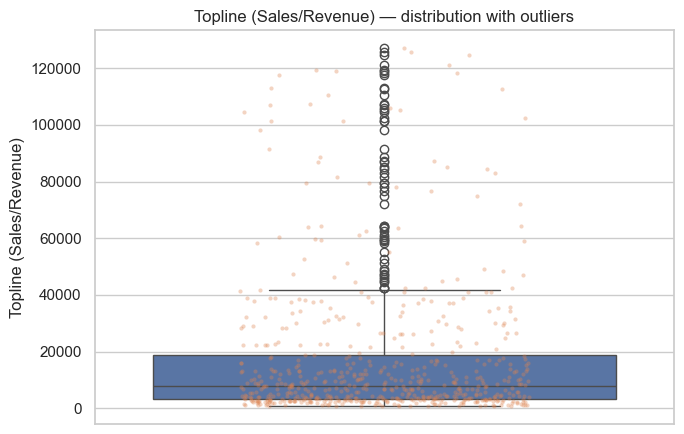

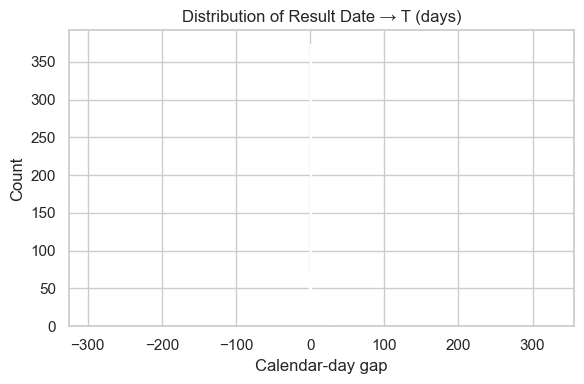

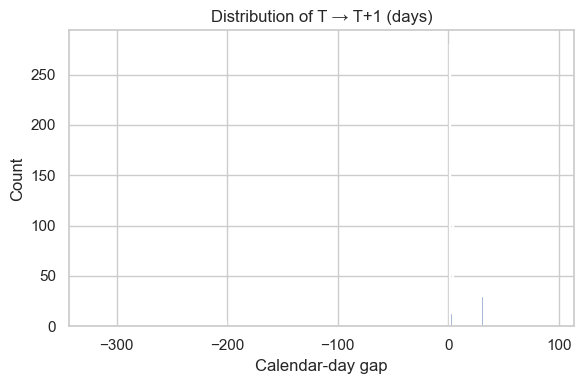

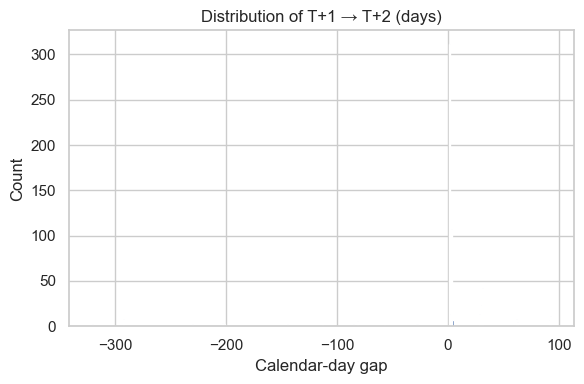

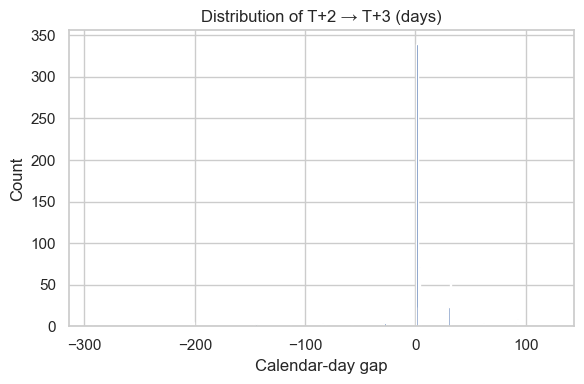

Most common gaps — Result Date → T (days)


,count
0,373
-1,67
-30,10
-2,10
-148,9
148,9
59,9
-294,8
-59,7
-118,6


Most common gaps — T → T+1 (days)


,count
1,280
3,127
31,41
30,30
92,14
2,13
91,12
4,9
-202,6
-29,6


Most common gaps — T+1 → T+2 (days)


,count
1,311
3,107
31,42
30,24
2,13
28,13
92,11
-293,8
61,8
91,7


Most common gaps — T+2 → T+3 (days)


,count
1,339
3,71
31,52
30,23
2,23
28,16
92,9
-293,6
-202,5
-85,4



3-Day Return (%) — summary:


,count,mean,std,min,5%,25%,50%,75%,95%,max,skew
value,584.0000,0.2936,4.2785,-12.0100,-6.6755,-2.2325,0.1500,2.8075,7.3040,19.0800,0.2317


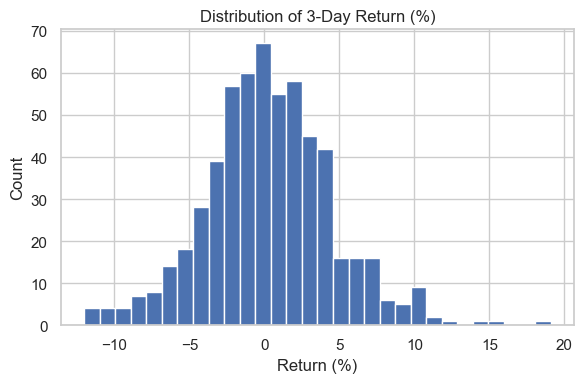

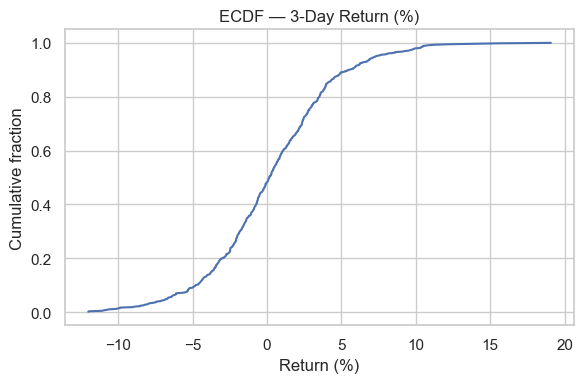


Movement Label balance:


,label,count,percent
0,0,344,58.9041
1,1,240,41.0959


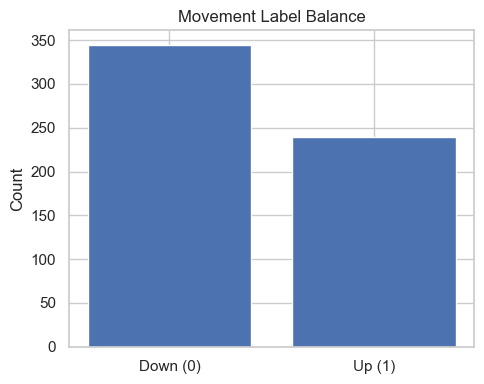


[Cell 3 complete]


In [39]:
# --- 0) Date coercion (safe, no mutation of original df) ---
date_cols = ["Result Date","_T_date","_T1_date","_T2_date","_T3_date"]
present_dates = [c for c in date_cols if c in df.columns]
d = df.copy()
for c in present_dates:
    d[c + "__dt"] = pd.to_datetime(d[c], errors="coerce", dayfirst=True)

def _days_between(a, b):
    """Return (b - a) in days; works with NaT -> NaN."""
    if a not in d.columns or b not in d.columns:
        return pd.Series(dtype="float64")
    a_dt = d[a]
    b_dt = d[b]
    out = (b_dt - a_dt).dt.days
    return out

# --- 1) Calendar-day gaps around the event window ---
gap_res_to_T   = _days_between("Result Date__dt", "_T_date__dt")     # should be >= 0 if T is exact/prior trade day
gap_T_to_T1    = _days_between("_T_date__dt", "_T1_date__dt")
gap_T1_to_T2   = _days_between("_T1_date__dt", "_T2_date__dt")
gap_T2_to_T3   = _days_between("_T2_date__dt", "_T3_date__dt")

print("Gaps (calendar days) — summary (drop NaNs):")
for name, s in [
    ("Result Date → T", gap_res_to_T),
    ("T → T+1", gap_T_to_T1),
    ("T+1 → T+2", gap_T1_to_T2),
    ("T+2 → T+3", gap_T2_to_T3),
]:
    s_clean = s.dropna()
    if len(s_clean) == 0:
        print(f"  {name}: no data")
        continue
    q = s_clean.describe(percentiles=[.05,.25,.5,.75,.95])
    print(f"  {name}: count={int(q['count'])}, min={q['min']:.0f}, p25={q['25%']:.0f}, "
          f"median={q['50%']:.0f}, p75={q['75%']:.0f}, p95={q['95%']:.0f}, max={q['max']:.0f}")

# Histograms for gaps (each as its own plot)
gap_series = {
    "Result Date → T (days)": gap_res_to_T,
    "T → T+1 (days)": gap_T_to_T1,
    "T+1 → T+2 (days)": gap_T1_to_T2,
    "T+2 → T+3 (days)": gap_T2_to_T3,
}
for title, s in gap_series.items():
    s_clean = s.dropna()
    if len(s_clean) == 0:
        continue
    plt.figure(figsize=(6,4))
    plt.hist(s_clean, bins=range(int(s_clean.min()) if np.isfinite(s_clean.min()) else 0,
                                 int(s_clean.max())+2 if np.isfinite(s_clean.max()) else 10))
    plt.title(f"Distribution of {title}")
    plt.xlabel("Calendar-day gap")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Also print most common gap sizes (helps spot weekends/holidays = 3,4-day gaps, etc.)
for title, s in gap_series.items():
    vc = s.dropna().astype(int).value_counts().head(10)
    if len(vc) == 0: 
        continue
    print(f"Most common gaps — {title}")
    display(vc.to_frame("count"))

# --- 2) 3-Day Return (%) distribution ---
ret_col = "3-Day Return (%)"
if ret_col in df.columns:
    ret = pd.to_numeric(df[ret_col], errors="coerce")
    ret_clean = ret.dropna()
    print("\n3-Day Return (%) — summary:")
    desc = ret_clean.describe(percentiles=[.05,.25,.5,.75,.95]).to_frame("value")
    desc.loc["skew"] = ret_clean.skew()
    display(desc.T)

    # Histogram
    plt.figure(figsize=(6,4))
    plt.hist(ret_clean, bins=30)
    plt.title("Distribution of 3-Day Return (%)")
    plt.xlabel("Return (%)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # ECDF
    x = np.sort(ret_clean.values)
    y = np.arange(1, len(x)+1) / len(x)
    plt.figure(figsize=(6,4))
    plt.plot(x, y)
    plt.title("ECDF — 3-Day Return (%)")
    plt.xlabel("Return (%)")
    plt.ylabel("Cumulative fraction")
    plt.tight_layout()
    plt.show()
else:
    print("\n[WARN] '3-Day Return (%)' not found in columns.")

# --- 3) Movement Label balance (Up vs Down) ---
lab_col = "Movement Label (1,0)"
if lab_col in df.columns:
    lab = pd.to_numeric(df[lab_col], errors="coerce").dropna().astype(int)
    counts = lab.value_counts().sort_index()  # ensure 0 then 1
    print("\nMovement Label balance:")
    display(pd.DataFrame({
        "label":[0,1],
        "count":[counts.get(0,0), counts.get(1,0)],
        "percent":[
            100*counts.get(0,0)/counts.sum() if counts.sum() else 0,
            100*counts.get(1,0)/counts.sum() if counts.sum() else 0
        ],
    }))

    plt.figure(figsize=(5,4))
    plt.bar(["Down (0)","Up (1)"], [counts.get(0,0), counts.get(1,0)])
    plt.title("Movement Label Balance")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("\n[WARN] 'Movement Label (1,0)' not found in columns.")

print("\n[Cell 3 complete]")


# ==== Feature distributions & Up/Down contrasts ====

Clean hist/KDEs for Return, EPS, OPM %, and Topline.

Sector/Cap boxplots for Return & EPS.

### A compact Up vs Down table with:
Welch t-test p-values (robust to unequal variances), Mann–Whitney U p-values (non-parametric), Cohen’s d and Cliff’s delta effect sizes, sample sizes per class.

### Violin/box 
overlays to visually compare distributions across labels.

Rows with valid labels (0/1): 584 / 585


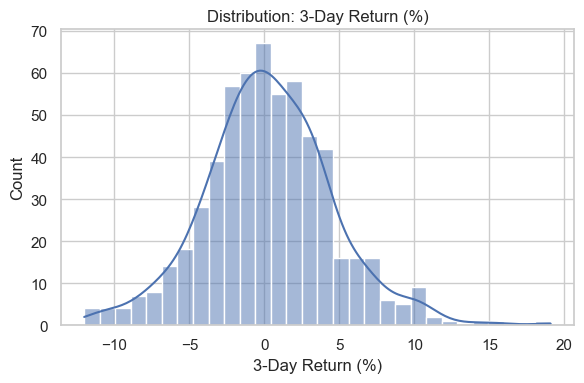

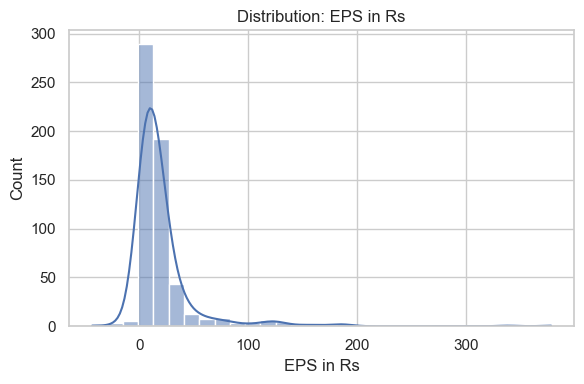

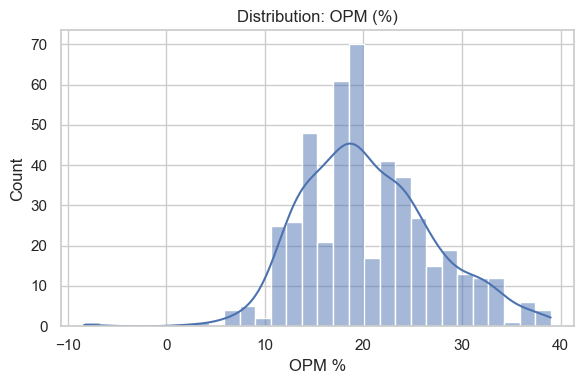

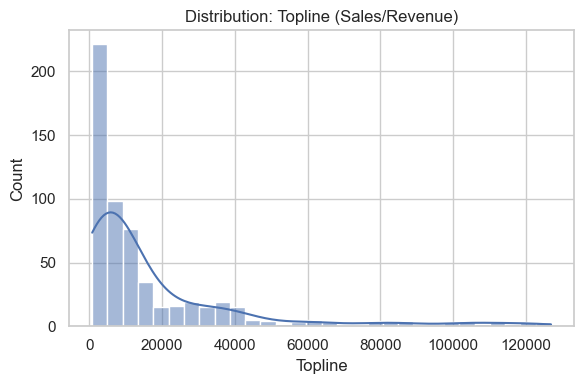

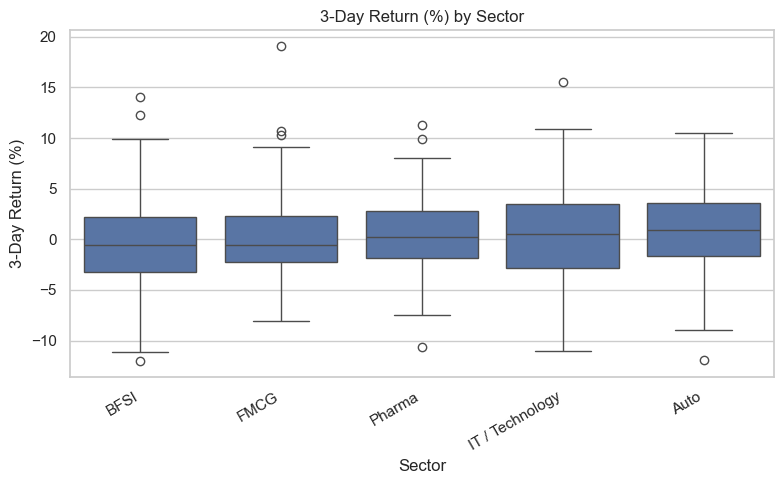

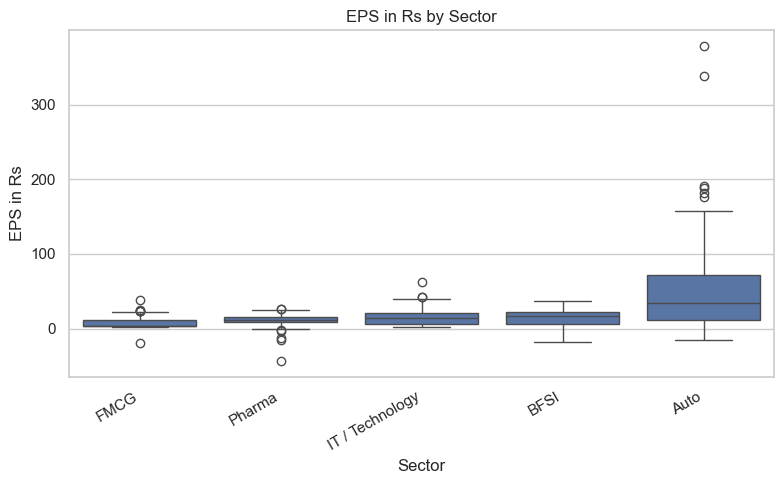

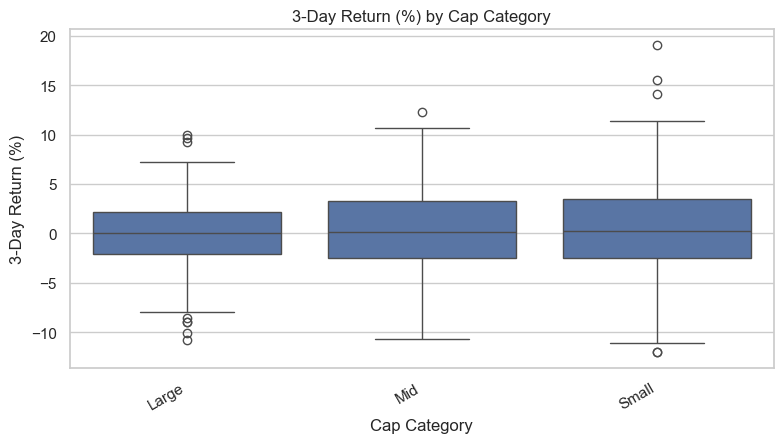

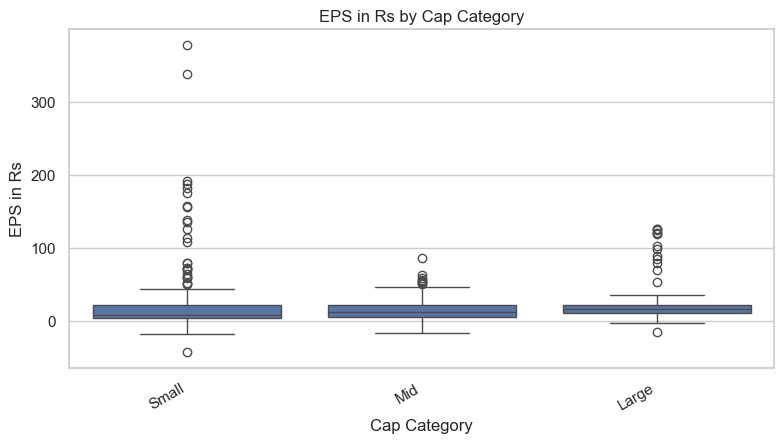

Up vs Down — contrasts (Welch t, Mann–Whitney; effect sizes):


,feature,n_down,n_up,mean_down,mean_up,median_down,median_up,welch_t_p,mw_u_p,cohens_d,cliffs_delta,welch_sig,mw_sig
0,3-Day Return (%),344,240,-2.4366,4.2068,-1.8600,3.4350,0.0000,0.0000,2.4073,1.0000,***,***
2,OPM %,266,201,21.0195,19.7846,20.0000,19.0000,0.0451,0.0723,-0.1883,-0.0970,*,
3,Net Profit,344,240,"3,044.3920","2,353.1322","1,019.5000",813.5000,0.0477,0.0271,-0.1627,-0.1074,*,*
4,Profit before tax,344,240,"3,980.0581","3,104.5363","1,372.5000","1,111.0000",0.0508,0.0364,-0.1606,-0.1017,,*
10,Interest,344,240,"4,170.3205","2,672.7825",77.0000,67.5000,0.0993,0.1432,-0.1324,-0.0712,,
9,Other Income,344,240,"2,840.3397","2,036.8657",186.0000,132.5000,0.2045,0.1150,-0.1035,-0.0766,,
7,Topline,344,240,"18,468.2765","16,426.4075","9,161.0000","6,903.5000",0.3200,0.0855,-0.0829,-0.0836,,
1,EPS in Rs,344,240,21.2966,18.9560,12.1000,13.0500,0.3743,0.7982,-0.0702,0.0124,,
11,Depreciation,344,240,395.1730,465.5375,152.5000,151.4250,0.3977,0.6295,0.0738,0.0234,,
13,Financing Margin %,78,39,0.1410,3.1795,-3.0000,-2.0000,0.4404,0.4521,0.1580,0.0858,,


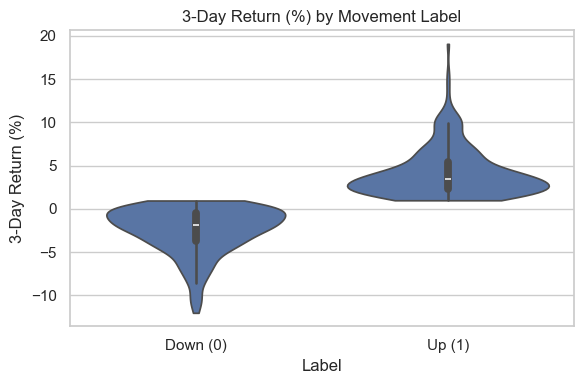

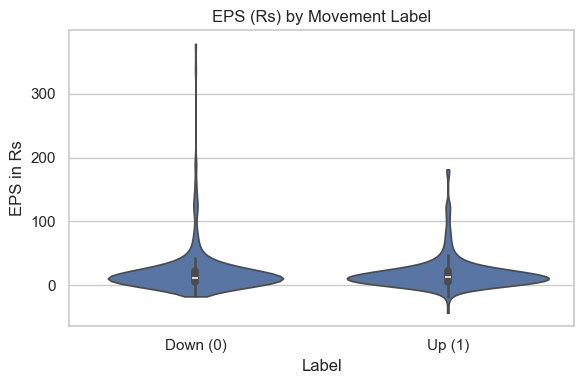

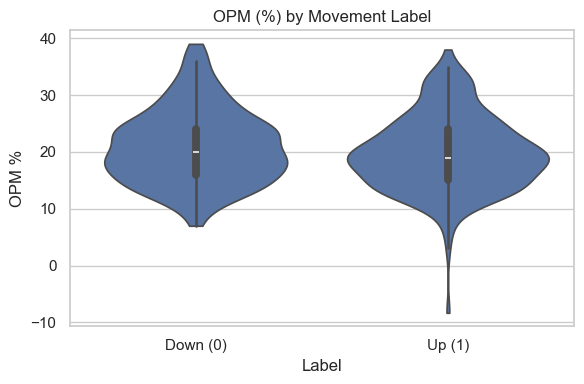

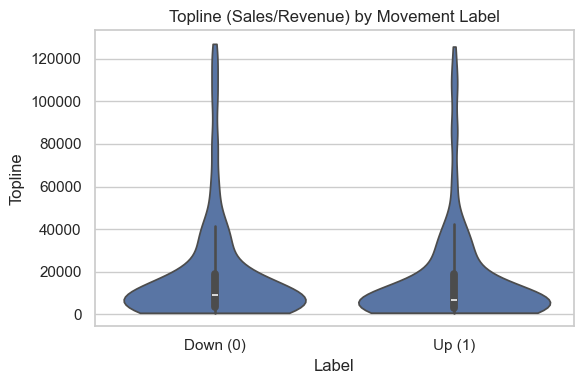

In [40]:
sns.set_theme(style="whitegrid")

# -----------------------------
# 0) Column handles & safe numerics
# -----------------------------
COL_RET   = "3-Day Return (%)"
COL_EPS   = "EPS in Rs"
COL_OPM   = "OPM %"
COL_PAT   = "Net Profit"
COL_PBT   = "Profit before tax"
COL_SALES = "Sales"
COL_REVEN = "Revenue"
COL_EXP   = "Expenses"
COL_OI    = "Other Income"
COL_INT   = "Interest"
COL_DEP   = "Depreciation"
COL_FPROF = "Financing Profit"
COL_FMAR  = "Financing Margin %"
COL_AVG3  = "3-Day Avg Price Post Result"
COL_SECTOR= "Sector"
COL_CAP   = "Cap Category"
COL_LAB   = "Movement Label (1,0)"

d = df.copy()

# Coerce numerics (keeps non-numerics as NaN)
num_cols = [c for c in [
    COL_RET, COL_EPS, COL_OPM, COL_PAT, COL_PBT, COL_SALES, COL_REVEN,
    COL_EXP, COL_OI, COL_INT, COL_DEP, COL_FPROF, COL_FMAR, COL_AVG3
] if c in d.columns]

for c in num_cols:
    d[c] = pd.to_numeric(d[c], errors="coerce")

# Topline feature (use Sales if present, else Revenue)
d["Topline"] = np.where(
    d.get(COL_SALES).notna() if COL_SALES in d.columns else False,
    d.get(COL_SALES, np.nan),
    d.get(COL_REVEN, np.nan)
)

# Clean label to {0,1}
if COL_LAB in d.columns:
    lab = pd.to_numeric(d[COL_LAB], errors="coerce").astype("Int64")
    d["_label_int"] = lab.fillna(-1).astype(int)
else:
    d["_label_int"] = -1

# Filter rows that have a valid label (0/1)
d_lab = d[d["_label_int"].isin([0,1])].copy()

print(f"Rows with valid labels (0/1): {len(d_lab)} / {len(d)}")

# -----------------------------
# 1) Distributions (full sample)
# -----------------------------
def hist_kde(series, title, bins=30):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) == 0:
        print(f"[Skip] No data for {title}")
        return
    plt.figure(figsize=(6,4))
    sns.histplot(s, bins=bins, stat="count", kde=True)
    plt.title(title)
    plt.tight_layout()
    plt.show()

hist_kde(d[COL_RET], "Distribution: 3-Day Return (%)")
hist_kde(d[COL_EPS], "Distribution: EPS in Rs")
hist_kde(d[COL_OPM], "Distribution: OPM (%)")
hist_kde(d["Topline"], "Distribution: Topline (Sales/Revenue)")

# -----------------------------
# 2) Boxplots by Sector and Cap (Return & EPS)
# -----------------------------
def box_by_group(df_, value_col, group_col, title):
    if value_col not in df_.columns or group_col not in df_.columns:
        print(f"[Skip] Missing columns for {title}")
        return
    t = df_[[value_col, group_col]].dropna()
    if len(t) == 0:
        print(f"[Skip] No data for {title}")
        return
    plt.figure(figsize=(8,4 + 0.2* t[group_col].nunique()))
    order = t.groupby(group_col)[value_col].median().sort_values().index
    sns.boxplot(data=t, x=group_col, y=value_col, order=order)
    plt.title(title)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

box_by_group(d, COL_RET, COL_SECTOR, "3-Day Return (%) by Sector")
box_by_group(d, COL_EPS, COL_SECTOR, "EPS in Rs by Sector")
box_by_group(d, COL_RET, COL_CAP,    "3-Day Return (%) by Cap Category")
box_by_group(d, COL_EPS, COL_CAP,    "EPS in Rs by Cap Category")

# -----------------------------
# 3) Up vs Down contrasts for key numeric features
#    (Welch t-test, Mann–Whitney U; Cohen's d, Cliff's delta)
# -----------------------------
def cohens_d(x, y):
    x = np.asarray(x); y = np.asarray(y)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    if (nx + ny - 2) <= 0:
        return np.nan
    s_pooled = np.sqrt(((nx-1)*vx + (ny-1)*vy) / (nx + ny - 2))
    if s_pooled == 0:
        return 0.0
    return (np.mean(x) - np.mean(y)) / s_pooled

def cliffs_delta(x, y):
    # returns delta in [-1,1]; positive means x > y tendency
    x = np.asarray(x); y = np.asarray(y)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    # efficient-ish for this dataset size
    diffs = np.subtract.outer(x, y)
    return (np.sum(diffs > 0) - np.sum(diffs < 0)) / diffs.size

def up_down_tests(df_, value_col, label_col="_label_int"):
    t = df_[[value_col, label_col]].dropna()
    t = t[t[label_col].isin([0,1])]
    g0 = t.loc[t[label_col]==0, value_col].astype(float).values
    g1 = t.loc[t[label_col]==1, value_col].astype(float).values
    n0, n1 = len(g0), len(g1)
    if n0 < 3 or n1 < 3:
        return {
            "feature": value_col, "n_down": n0, "n_up": n1,
            "mean_down": np.nan, "mean_up": np.nan,
            "median_down": np.nan, "median_up": np.nan,
            "welch_t_p": np.nan, "mw_u_p": np.nan,
            "cohens_d": np.nan, "cliffs_delta": np.nan
        }
    # Welch t-test (unequal variances)
    welch = st.ttest_ind(g1, g0, equal_var=False, nan_policy="omit")
    # Mann–Whitney U (two-sided)
    try:
        mw = st.mannwhitneyu(g1, g0, alternative="two-sided")
        mw_p = mw.pvalue
    except Exception:
        mw_p = np.nan
    return {
        "feature": value_col,
        "n_down": n0, "n_up": n1,
        "mean_down": float(np.mean(g0)), "mean_up": float(np.mean(g1)),
        "median_down": float(np.median(g0)), "median_up": float(np.median(g1)),
        "welch_t_p": float(welch.pvalue) if hasattr(welch, "pvalue") else np.nan,
        "mw_u_p": float(mw_p),
        "cohens_d": float(cohens_d(g1, g0)),          # positive -> Up(1) > Down(0)
        "cliffs_delta": float(cliffs_delta(g1, g0)),  # positive -> Up(1) > Down(0)
    }

features_to_test = [c for c in [
    COL_RET, COL_EPS, COL_OPM, COL_PAT, COL_PBT, COL_SALES, COL_REVEN,
    "Topline", COL_EXP, COL_OI, COL_INT, COL_DEP, COL_FPROF, COL_FMAR, COL_AVG3
] if c in d.columns]

results = [up_down_tests(d_lab, c) for c in features_to_test]
res_df = pd.DataFrame(results)

# Order by smallest Welch p-value, then absolute effect size
res_df = res_df.sort_values(["welch_t_p", "mw_u_p"], na_position="last")

def _stars(p):
    if pd.isna(p): return ""
    return "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))

show_cols = [
    "feature","n_down","n_up","mean_down","mean_up","median_down","median_up",
    "welch_t_p","mw_u_p","cohens_d","cliffs_delta"
]
out = res_df[show_cols].copy()
out["welch_sig"] = out["welch_t_p"].map(_stars)
out["mw_sig"]    = out["mw_u_p"].map(_stars)

print("Up vs Down — contrasts (Welch t, Mann–Whitney; effect sizes):")
display(out.head(15))

# -----------------------------
# 4) Visual contrasts (violin/box) for a few key features
# -----------------------------
def violin_updown(col, title):
    if col not in d_lab.columns:
        print(f"[Skip] {col} not in data.")
        return
    t = d_lab[[col, "_label_int"]].dropna()
    if len(t) < 10:
        print(f"[Skip] Not enough data to plot {col}.")
        return
    t["Label"] = t["_label_int"].map({0:"Down (0)", 1:"Up (1)"})
    plt.figure(figsize=(6,4))
    sns.violinplot(data=t, x="Label", y=col, inner="box", cut=0)
    plt.title(title)
    plt.tight_layout()
    plt.show()

violin_updown(COL_RET, "3-Day Return (%) by Movement Label")
violin_updown(COL_EPS, "EPS (Rs) by Movement Label")
violin_updown(COL_OPM, "OPM (%) by Movement Label")
violin_updown("Topline", "Topline (Sales/Revenue) by Movement Label")



# ==== Correlations & importance previews ====

A Spearman heatmap to reveal clusters (e.g., EPS ↔ PAT ↔ OPM%).

Top correlations vs. 3-Day Return (Pearson & Spearman).

Point-biserial r and Mutual Information w.r.t. the binary label.

A concise list of highly collinear feature pairs (useful before modeling).

Numeric columns considered: 18
Rows with valid label (0/1): 584 / 585
Rows with both valid Return & label: 584 / 585


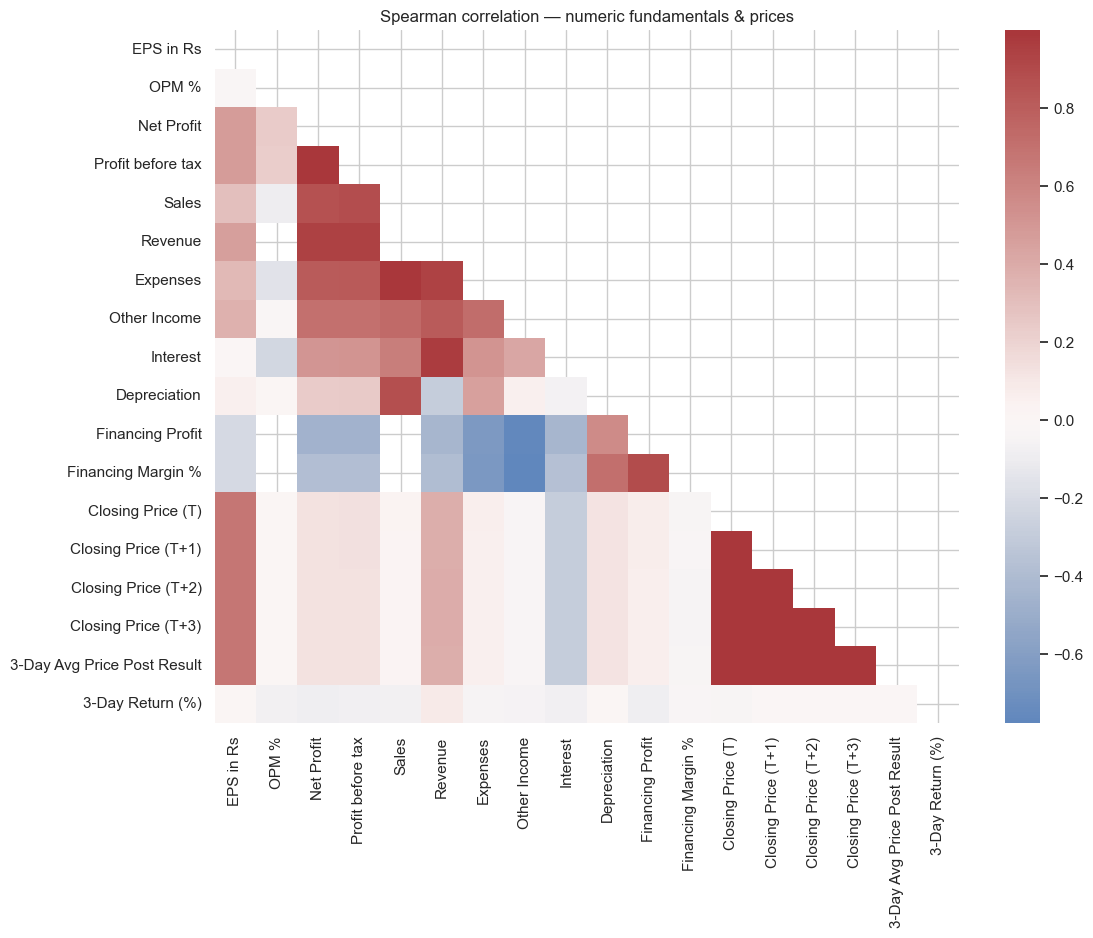

[saved] cell_5\corr_spearman_heatmap.png
[saved] cell_5\corr_spearman_matrix.csv


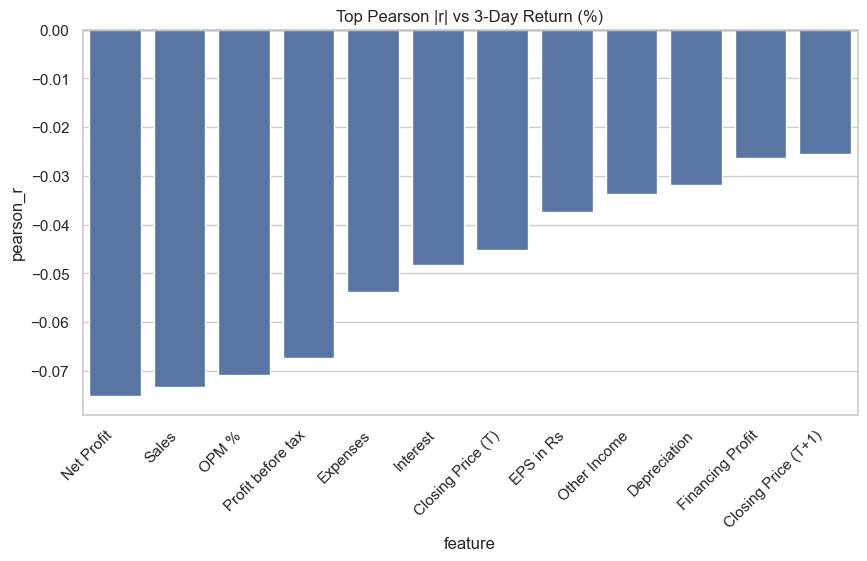

[saved] cell_5\top_pearson_vs_return.png


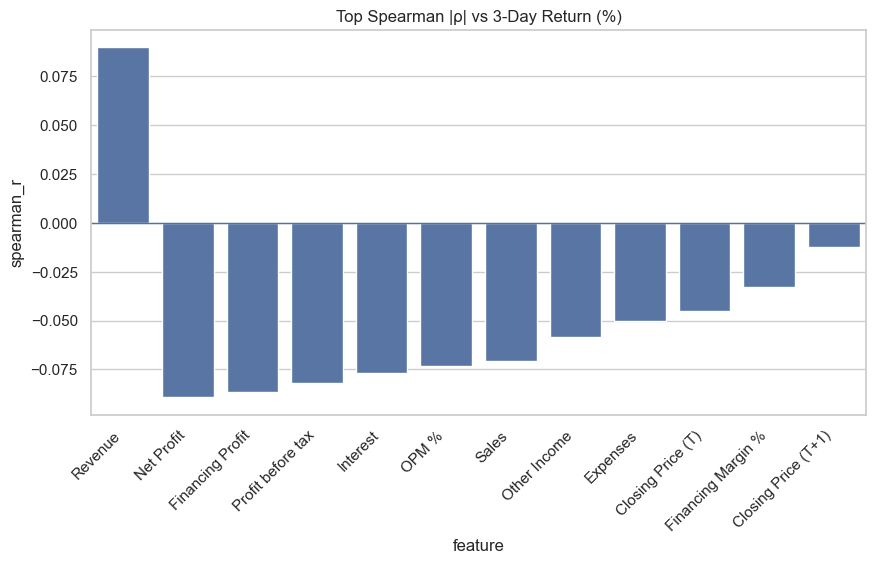

[saved] cell_5\top_spearman_vs_return.png


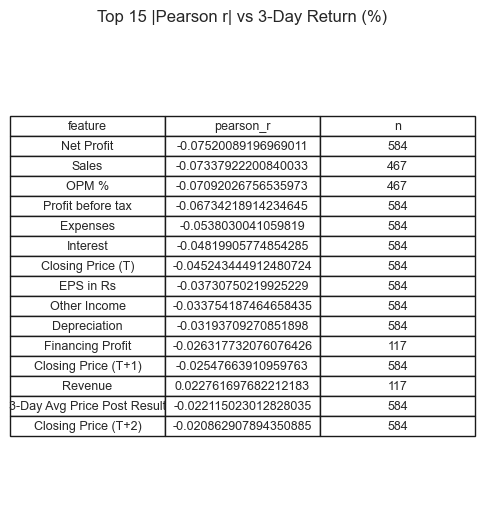

[saved] cell_5\table_top15_pearson_vs_return.png
[saved] cell_5\table_pearson_vs_return_full.csv


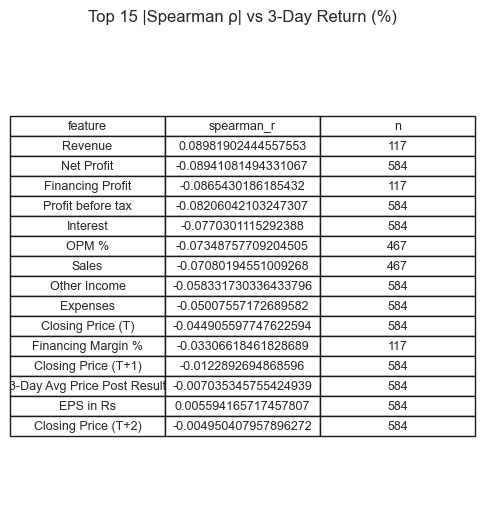

[saved] cell_5\table_top15_spearman_vs_return.png
[saved] cell_5\table_spearman_vs_return_full.csv


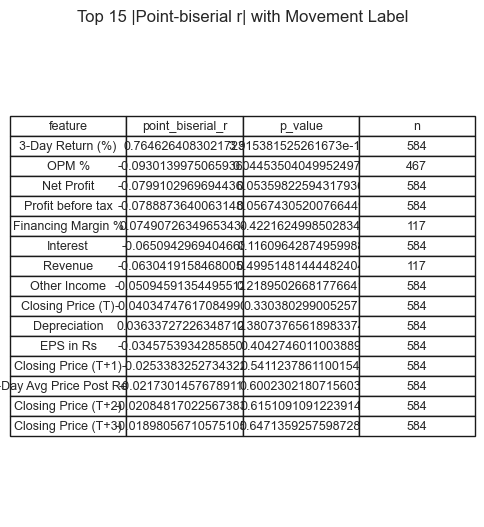

[saved] cell_5\table_top15_point_biserial.png
[saved] cell_5\table_point_biserial_full.csv


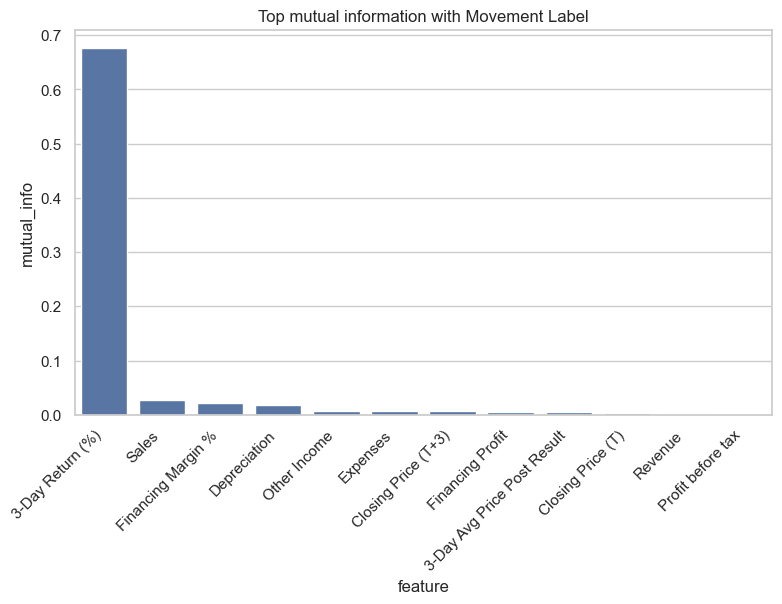

[saved] cell_5\top_mutual_info.png


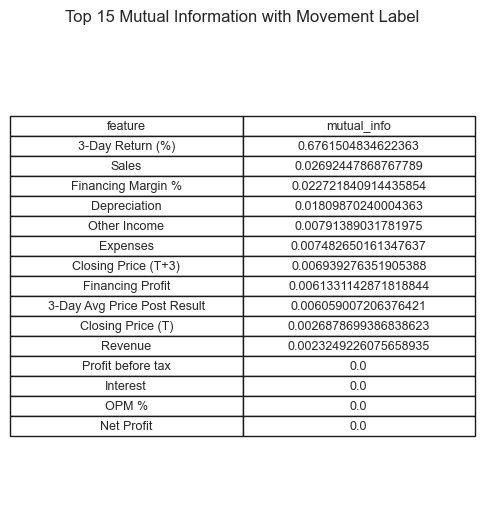

[saved] cell_5\table_top15_mutual_info.png
[saved] cell_5\table_mutual_info_full.csv


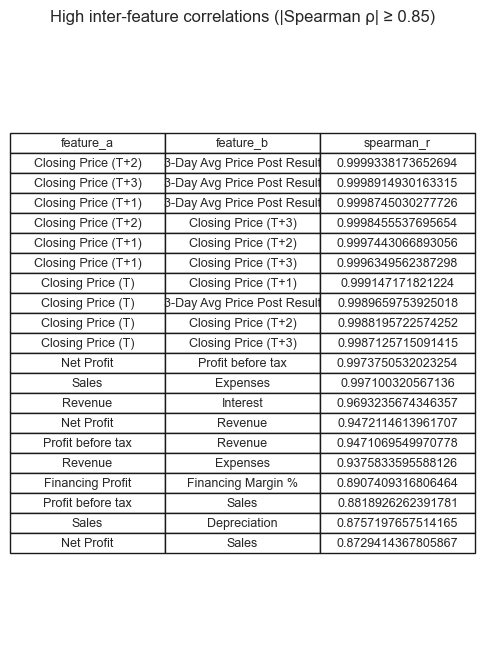

[saved] cell_5\table_high_collinearity_pairs.png
[saved] cell_5\table_high_collinearity_pairs_full.csv

[Cell 5 complete — charts & tables saved under ./cell_5/ ]


In [43]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from pathlib import Path

sns.set_theme(style="whitegrid")

# -----------------------------
# Output folder per cell
# -----------------------------
OUTDIR = Path("cell_5")
OUTDIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, filename, dpi=200):
    display(fig)
    path = OUTDIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    print(f"[saved] {path}")

def save_df_image(df, filename, title=None, max_rows=None, fontsize=9):
    """
    Render a small/medium DataFrame as a PNG using matplotlib's table.
    """
    if max_rows is not None and len(df) > max_rows:
        df = df.head(max_rows).copy()

    n_rows, n_cols = df.shape
    # Heuristic sizing
    col_w = 1.2 if n_cols <= 6 else 0.9
    row_h = 0.35
    w = max(6, min(22, n_cols * col_w))
    h = max(2.5, min(18, 1.0 + n_rows * row_h))

    fig, ax = plt.subplots(figsize=(w, h))
    ax.axis("off")
    if title:
        ax.set_title(title, pad=10)

    # Build table
    tbl = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.scale(1, 1.2)  # a bit taller rows

    save_fig(fig, filename)

# -----------------------------
# Column handles
# -----------------------------
COL_RET = "3-Day Return (%)"
COL_LAB = "Movement Label (1,0)"

numeric_candidates = [
    "EPS in Rs", "OPM %", "Net Profit", "Profit before tax",
    "Sales", "Revenue", "Expenses", "Other Income", "Interest", "Depreciation",
    "Financing Profit", "Financing Margin %",
    "Closing Price (T)", "Closing Price (T+1)", "Closing Price (T+2)", "Closing Price (T+3)",
    "3-Day Avg Price Post Result", COL_RET
]
numeric_cols = [c for c in numeric_candidates if c in df.columns]

# Coerce numerics
Xnum = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
y_lab = pd.to_numeric(df.get(COL_LAB, pd.Series(index=df.index)), errors="coerce")

# For some summaries we need rows with valid return & label
mask_ret = Xnum[COL_RET].notna() if COL_RET in Xnum.columns else pd.Series(False, index=df.index)
mask_lab = y_lab.isin([0, 1])
mask_both = mask_ret & mask_lab

print(f"Numeric columns considered: {len(numeric_cols)}")
print(f"Rows with valid label (0/1): {mask_lab.sum()} / {len(df)}")
print(f"Rows with both valid Return & label: {mask_both.sum()} / {len(df)}")

# -----------------------------
# 1) Spearman correlation heatmap (numeric ↔ numeric)
# -----------------------------
corr_spear = Xnum.corr(method="spearman", min_periods=20)

fig = plt.figure(figsize=(12, 9))
ax = plt.gca()
mask = np.triu(np.ones_like(corr_spear, dtype=bool))
sns.heatmap(corr_spear, mask=mask, annot=False, cmap="vlag", center=0, ax=ax)
ax.set_title("Spearman correlation — numeric fundamentals & prices")
save_fig(fig, "corr_spearman_heatmap.png")

# Also save corr matrix as CSV for reference (optional)
corr_spear.to_csv(OUTDIR / "corr_spearman_matrix.csv", index=True)
print(f"[saved] {OUTDIR/'corr_spearman_matrix.csv'}")

# -----------------------------
# 2) Pearson & Spearman vs Return (%)
# -----------------------------
def corr_to_target(frame, target_col, method="pearson", min_n=30):
    out = []
    t = pd.to_numeric(frame[target_col], errors="coerce")
    for c in frame.columns:
        if c == target_col:
            continue
        s = pd.to_numeric(frame[c], errors="coerce")
        pair = pd.concat([t, s], axis=1).dropna()
        if len(pair) >= min_n:
            r = pair.corr(method=method).iloc[0, 1]
            out.append((c, r, len(pair)))
    res = pd.DataFrame(out, columns=["feature", f"{method}_r", "n"])
    return res.sort_values(f"{method}_r", key=lambda x: x.abs(), ascending=False)

if COL_RET in Xnum.columns:
    pearson_vs_ret  = corr_to_target(Xnum, COL_RET, method="pearson")
    spearman_vs_ret = corr_to_target(Xnum, COL_RET, method="spearman")
    topN = 12

    # Pearson bar
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=pearson_vs_ret.head(topN), x="feature", y="pearson_r", ax=ax)
    ax.axhline(0, linewidth=1)
    ax.set_title("Top Pearson |r| vs 3-Day Return (%)")
    ax.tick_params(axis="x", labelrotation=45)
    for lab in ax.get_xticklabels():
        lab.set_horizontalalignment("right")
    save_fig(fig, "top_pearson_vs_return.png")

    # Spearman bar
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=spearman_vs_ret.head(topN), x="feature", y="spearman_r", ax=ax)
    ax.axhline(0, linewidth=1)
    ax.set_title("Top Spearman |ρ| vs 3-Day Return (%)")
    ax.tick_params(axis="x", labelrotation=45)
    for lab in ax.get_xticklabels():
        lab.set_horizontalalignment("right")
    save_fig(fig, "top_spearman_vs_return.png")

    # Save top tables as images & CSV
    save_df_image(pearson_vs_ret.head(15), "table_top15_pearson_vs_return.png",
                  title="Top 15 |Pearson r| vs 3-Day Return (%)", max_rows=15)
    pearson_vs_ret.to_csv(OUTDIR / "table_pearson_vs_return_full.csv", index=False)
    print(f"[saved] {OUTDIR/'table_pearson_vs_return_full.csv'}")

    save_df_image(spearman_vs_ret.head(15), "table_top15_spearman_vs_return.png",
                  title="Top 15 |Spearman ρ| vs 3-Day Return (%)", max_rows=15)
    spearman_vs_ret.to_csv(OUTDIR / "table_spearman_vs_return_full.csv", index=False)
    print(f"[saved] {OUTDIR/'table_spearman_vs_return_full.csv'}")
else:
    print("[Skip] '3-Day Return (%)' not found for target correlations.")

# -----------------------------
# 3) Point-biserial correlation (numeric ↔ Movement Label)
# -----------------------------
pbs_rows = []
if mask_lab.sum() >= 30:
    for c in numeric_cols:
        s = pd.to_numeric(df[c], errors="coerce")
        pair = pd.concat([y_lab, s], axis=1).dropna()
        pair = pair[pair[COL_LAB].isin([0, 1])]
        if len(pair) >= 30:
            r, p = st.pointbiserialr(pair[COL_LAB].astype(int), pair[c].astype(float))
            pbs_rows.append((c, r, p, len(pair)))
    pbs_df = pd.DataFrame(pbs_rows, columns=["feature", "point_biserial_r", "p_value", "n"]) \
               .sort_values("point_biserial_r", key=lambda x: x.abs(), ascending=False)

    # Save table as image & CSV
    save_df_image(pbs_df.head(15), "table_top15_point_biserial.png",
                  title="Top 15 |Point-biserial r| with Movement Label", max_rows=15)
    pbs_df.to_csv(OUTDIR / "table_point_biserial_full.csv", index=False)
    print(f"[saved] {OUTDIR/'table_point_biserial_full.csv'}")
else:
    print("[Skip] Not enough rows with a valid Movement Label for point-biserial correlation.")

# -----------------------------
# 4) Mutual information (numeric ↔ Movement Label)
# -----------------------------
if mask_lab.sum() >= 30:
    # Prepare X (median-imputed) and y
    X_mi = df.loc[mask_lab, numeric_cols].copy()
    for c in X_mi.columns:
        X_mi[c] = pd.to_numeric(X_mi[c], errors="coerce")
        X_mi[c] = X_mi[c].fillna(X_mi[c].median())
    y_mi = y_lab.loc[mask_lab].astype(int)

    # Scale for stability
    X_scaled = pd.DataFrame(StandardScaler().fit_transform(X_mi), columns=X_mi.columns, index=X_mi.index)

    mi = mutual_info_classif(X_scaled, y_mi, discrete_features=False, random_state=42)
    mi_df = pd.DataFrame({"feature": X_scaled.columns, "mutual_info": mi}) \
              .sort_values("mutual_info", ascending=False)

    # MI bar chart
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=mi_df.head(12), x="feature", y="mutual_info", ax=ax)
    ax.tick_params(axis="x", labelrotation=45)
    for lab in ax.get_xticklabels():
        lab.set_horizontalalignment("right")
    ax.set_title("Top mutual information with Movement Label")
    save_fig(fig, "top_mutual_info.png")

    # Save table as image & CSV
    save_df_image(mi_df.head(15), "table_top15_mutual_info.png",
                  title="Top 15 Mutual Information with Movement Label", max_rows=15)
    mi_df.to_csv(OUTDIR / "table_mutual_info_full.csv", index=False)
    print(f"[saved] {OUTDIR/'table_mutual_info_full.csv'}")
else:
    print("[Skip] Not enough rows with a valid Movement Label for mutual information.")

# -----------------------------
# 5) Multicollinearity flags (high inter-feature correlation)
# -----------------------------
pairs = []
thr = 0.85  # threshold to flag
c = corr_spear.copy()
for i, a in enumerate(c.columns):
    for j, b in enumerate(c.columns):
        if j <= i:
            continue
        r = c.loc[a, b]
        if pd.notna(r) and abs(r) >= thr:
            pairs.append((a, b, r))
high_collinear = pd.DataFrame(pairs, columns=["feature_a", "feature_b", "spearman_r"]) \
                   .sort_values("spearman_r", key=lambda x: x.abs(), ascending=False)

# Save as image & CSV
save_df_image(high_collinear.head(20), "table_high_collinearity_pairs.png",
              title=f"High inter-feature correlations (|Spearman ρ| ≥ {thr})", max_rows=20)
high_collinear.to_csv(OUTDIR / "table_high_collinearity_pairs_full.csv", index=False)
print(f"[saved] {OUTDIR/'table_high_collinearity_pairs_full.csv'}")

print("\n[Cell 5 complete — charts & tables saved under ./cell_5/ ]")


# ==== Time & seasonality views (with image exports) ====

In [44]:
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid")

# -----------------------------
# Output folder per cell
# -----------------------------
OUTDIR = Path("cell_6")
OUTDIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, filename, dpi=200):
    path = OUTDIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    print(f"[saved] {path}")

def save_df_image(df_in, filename, title=None, max_rows=None, fontsize=9):
    df = df_in.copy()
    if max_rows is not None and len(df) > max_rows:
        df = df.head(max_rows)

    n_rows, n_cols = df.shape
    col_w = 1.1 if n_cols <= 6 else 0.9
    row_h = 0.35
    w = max(6, min(22, n_cols * col_w))
    h = max(2.5, min(18, 1.0 + n_rows * row_h))

    fig, ax = plt.subplots(figsize=(w, h))
    ax.axis("off")
    if title:
        ax.set_title(title, pad=10)

    tbl = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.scale(1, 1.2)
    save_fig(fig, filename)

# -----------------------------
# Columns & parsing helpers
# -----------------------------
COL_RET = "3-Day Return (%)"
COL_EPS = "EPS in Rs"
COL_OPM = "OPM %"
COL_PERIOD = "Period"
COL_RDATE = "Result Date"

# Parse Period to a proper month-end date (e.g., "Jun 2024" -> 2024-06-30)
def parse_period_to_month_end(x):
    if pd.isna(x):
        return pd.NaT
    # If it's already a datetime-like, coerce to month-end
    if isinstance(x, (pd.Timestamp, np.datetime64)):
        dt = pd.to_datetime(x, errors="coerce")
        return (dt + pd.offsets.MonthEnd(0)) if pd.notna(dt) else pd.NaT
    # If it's a string like "Jun 2024"
    s = str(x).strip()
    # common patterns: "Jun 2024", "June 2024", "2024-06", etc.
    for fmt in ["%b %Y", "%B %Y", "%Y-%m", "%Y-%m-%d"]:
        try:
            dt = pd.to_datetime(s, format=fmt)
            return dt + pd.offsets.MonthEnd(0)
        except Exception:
            continue
    # last resort generic parser
    dt = pd.to_datetime(s, errors="coerce")
    return (dt + pd.offsets.MonthEnd(0)) if pd.notna(dt) else pd.NaT

df = df.copy()

# Derive quarter_end from Period (preferred). If missing, fall back to Result Date month-end.
quarter_end = df[COL_PERIOD].apply(parse_period_to_month_end)
fallback = pd.to_datetime(df[COL_RDATE], errors="coerce") + pd.offsets.MonthEnd(0)
df["_QuarterEnd"] = quarter_end.fillna(fallback)

# Fiscal quarter buckets (India FY: Q1=Apr-Jun, Q2=Jul-Sep, Q3=Oct-Dec, Q4=Jan-Mar)
def fiscal_quarter_from_month(m):
    if pd.isna(m): 
        return np.nan
    m = int(m)
    if m in (4, 5, 6):   return "Q1 (Apr–Jun)"
    if m in (7, 8, 9):   return "Q2 (Jul–Sep)"
    if m in (10, 11, 12):return "Q3 (Oct–Dec)"
    if m in (1, 2, 3):   return "Q4 (Jan–Mar)"
    return np.nan

df["_FiscalQ"] = df["_QuarterEnd"].dt.month.apply(fiscal_quarter_from_month)
df["_QuarterEnd"] = pd.to_datetime(df["_QuarterEnd"], errors="coerce")

# -----------------------------
# Median 3-Day Return (%) by quarter (chronological)
# -----------------------------
ret_series = pd.to_numeric(df[COL_RET], errors="coerce")
ts_ret = (
    pd.DataFrame({"QuarterEnd": df["_QuarterEnd"], COL_RET: ret_series})
      .dropna(subset=["QuarterEnd", COL_RET])
      .groupby("QuarterEnd", as_index=True)[COL_RET]
      .median()
      .sort_index()
)

print(f"[info] Quarterly median return points: {len(ts_ret)} "
      f"({ts_ret.index.min().date() if len(ts_ret) else 'NA'} → "
      f"{ts_ret.index.max().date() if len(ts_ret) else 'NA'})")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ts_ret.index, ts_ret.values, marker="o", linewidth=2)
ax.axhline(0, linewidth=1)
ax.set_title("Median 3-Day Return (%) by Quarter (chronological)")
ax.set_xlabel("Quarter end")
ax.set_ylabel("Median 3-Day Return (%)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}%"))
save_fig(fig, "median_return_by_quarter.png")

# Save the time series as a small table image & CSV
ts_ret_df = ts_ret.reset_index().rename(columns={"QuarterEnd": "Quarter End"})
save_df_image(ts_ret_df, "table_median_return_by_quarter.png",
              title="Median 3-Day Return (%) by Quarter", max_rows=40)
ts_ret_df.to_csv(OUTDIR / "median_return_by_quarter.csv", index=False)
print(f"[saved] {OUTDIR/'median_return_by_quarter.csv'}")

# -----------------------------
# Median EPS & OPM % by quarter (chronological)
# -----------------------------
eps_series = pd.to_numeric(df.get(COL_EPS), errors="coerce")
opm_series = pd.to_numeric(df.get(COL_OPM), errors="coerce")

by_q = pd.DataFrame({
    "QuarterEnd": df["_QuarterEnd"],
    "EPS": eps_series,
    "OPM": opm_series
}).dropna(subset=["QuarterEnd"])

med_e = by_q.groupby("QuarterEnd")["EPS"].median().sort_index()
med_o = by_q.groupby("QuarterEnd")["OPM"].median().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(med_e.index, med_e.values, marker="o", linewidth=2)
ax.set_title("Median EPS (₹) by Quarter")
ax.set_xlabel("Quarter end")
ax.set_ylabel("EPS (₹)")
save_fig(fig, "median_eps_by_quarter.png")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(med_o.index, med_o.values, marker="o", linewidth=2)
ax.set_title("Median OPM (%) by Quarter")
ax.set_xlabel("Quarter end")
ax.set_ylabel("OPM (%)")
save_fig(fig, "median_opm_by_quarter.png")

med_tbl = (
    pd.DataFrame({"EPS_median": med_e, "OPM%_median": med_o})
      .reset_index()
      .rename(columns={"QuarterEnd": "Quarter End"})
)
save_df_image(med_tbl, "table_median_eps_opm_by_quarter.png",
              title="Median EPS & OPM% by Quarter", max_rows=40)
med_tbl.to_csv(OUTDIR / "median_eps_opm_by_quarter.csv", index=False)
print(f"[saved] {OUTDIR/'median_eps_opm_by_quarter.csv'}")

# -----------------------------
# Seasonal boxplots: return by fiscal quarter bucket
# -----------------------------
season_df = pd.DataFrame({
    "FiscalQ": df["_FiscalQ"],
    COL_RET: ret_series
}).dropna(subset=["FiscalQ", COL_RET])

order = ["Q1 (Apr–Jun)", "Q2 (Jul–Sep)", "Q3 (Oct–Dec)", "Q4 (Jan–Mar)"]

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=season_df, x="FiscalQ", y=COL_RET, order=order, ax=ax)
sns.stripplot(data=season_df, x="FiscalQ", y=COL_RET, order=order, ax=ax, alpha=0.35, jitter=True)
ax.axhline(0, linewidth=1)
ax.set_title("3-Day Return (%) by Fiscal Quarter")
ax.set_xlabel("Fiscal quarter (India FY)")
ax.set_ylabel("3-Day Return (%)")
save_fig(fig, "seasonal_boxplot_return_by_fiscalQ.png")

# Summary table per FiscalQ
season_tbl = season_df.groupby("FiscalQ")[COL_RET] \
                      .agg(n="count", mean="mean", median="median", std="std") \
                      .reindex(order)
save_df_image(season_tbl.reset_index(), "table_return_by_fiscalQ.png",
              title="Returns by fiscal quarter — summary")
season_tbl.to_csv(OUTDIR / "return_by_fiscalQ_summary.csv")
print(f"[saved] {OUTDIR/'return_by_fiscalQ_summary.csv'}")

print("\n[Cell 6 complete — charts & tables saved under ./cell_6/ ]")


[info] Quarterly median return points: 14 (2022-03-31 → 2025-06-30)
[saved] cell_6\median_return_by_quarter.png
[saved] cell_6\table_median_return_by_quarter.png
[saved] cell_6\median_return_by_quarter.csv
[saved] cell_6\median_eps_by_quarter.png
[saved] cell_6\median_opm_by_quarter.png
[saved] cell_6\table_median_eps_opm_by_quarter.png
[saved] cell_6\median_eps_opm_by_quarter.csv
[saved] cell_6\seasonal_boxplot_return_by_fiscalQ.png
[saved] cell_6\table_return_by_fiscalQ.png
[saved] cell_6\return_by_fiscalQ_summary.csv

[Cell 6 complete — charts & tables saved under ./cell_6/ ]


# ==== Cross-plots (relationships) ====


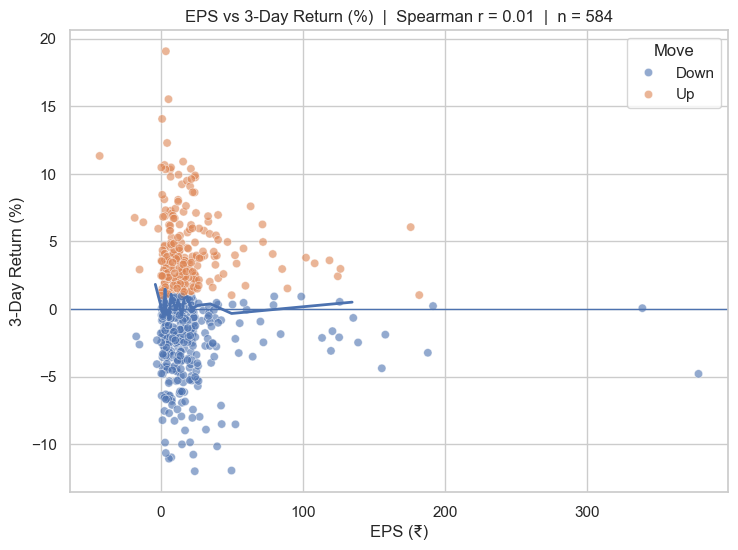

[saved] cell_7\scatter_eps_vs_return.png
[saved] cell_7\scatter_opm_vs_netprofit_by_sector.png
[saved] cell_7\table_corr_opm_netprofit_by_sector.png
[saved] cell_7\scatter_topline_vs_return_logx.png
[saved] cell_7\scatter_bfsi_fmargin_vs_return.png
[saved] cell_7\table_bfsi_fmargin_return_summary.png


In [45]:
# -------------------------------------------------
# Output folder + lightweight save helpers
# -------------------------------------------------
OUTDIR = Path("cell_7")
OUTDIR.mkdir(parents=True, exist_ok=True)

if "save_fig" not in globals():
    def save_fig(fig, filename, dpi=200):
        path = OUTDIR / filename
        fig.tight_layout()
        fig.savefig(path, dpi=dpi, bbox_inches="tight")
        plt.close(fig)
        print(f"[saved] {path}")

if "save_df_image" not in globals():
    def save_df_image(df_in, filename, title=None, max_rows=None, fontsize=9):
        dfx = df_in.copy()
        if max_rows is not None and len(dfx) > max_rows:
            dfx = dfx.head(max_rows)
        n_rows, n_cols = dfx.shape
        col_w = 1.1 if n_cols <= 6 else 0.9
        row_h = 0.35
        w = max(6, min(22, n_cols * col_w))
        h = max(2.5, min(18, 1.0 + n_rows * row_h))
        fig, ax = plt.subplots(figsize=(w, h))
        ax.axis("off")
        if title:
            ax.set_title(title, pad=10)
        tbl = ax.table(
            cellText=dfx.values,
            colLabels=dfx.columns,
            loc="center",
            cellLoc="center",
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(fontsize)
        tbl.scale(1, 1.2)
        save_fig(fig, filename)

# -------------------------------------------------
# Columns (as in your clean_data)
# -------------------------------------------------
COL_RET   = "3-Day Return (%)"
COL_EPS   = "EPS in Rs"
COL_OPM   = "OPM %"
COL_NP    = "Net Profit"
COL_SALES = "Sales"
COL_REV   = "Revenue"
COL_SECT  = "Sector"
COL_MOVE  = "Movement Label (1,0)"
COL_TOPL  = "_Topline_for_plots"

# Build a unified topline measure: prefer Sales, else Revenue
df = df.copy()
df[COL_TOPL] = pd.to_numeric(df[COL_SALES], errors="coerce")
rev_num = pd.to_numeric(df[COL_REV], errors="coerce")
df.loc[df[COL_TOPL].isna(), COL_TOPL] = rev_num

# Movement label (string) for coloring
move_map = {1: "Up", 0: "Down"}
df["_MoveLabel"] = pd.Series(df[COL_MOVE]).map(move_map)

# Quick numeric parses
eps_num  = pd.to_numeric(df[COL_EPS], errors="coerce")
opm_num  = pd.to_numeric(df[COL_OPM], errors="coerce")
np_num   = pd.to_numeric(df[COL_NP], errors="coerce")
ret_num  = pd.to_numeric(df[COL_RET], errors="coerce")
top_num  = pd.to_numeric(df[COL_TOPL], errors="coerce")
fm_num   = pd.to_numeric(df.get("Financing Margin %"), errors="coerce")

# -------------------------------------------------
# Helper: binned smoother (LOWESS-like без statsmodels)
# -------------------------------------------------
def binned_smoother(x, y, bins=20, min_bin=10):
    """Return bin-center x and mean y per quantile bin (robust, dependency-free)."""
    ok = (~pd.isna(x)) & (~pd.isna(y))
    x = np.asarray(x[ok], float)
    y = np.asarray(y[ok], float)
    if x.size < min_bin:
        return np.array([]), np.array([])
    # Quantile bins
    qs = np.linspace(0, 1, bins + 1)
    edges = np.quantile(x, qs)
    # Avoid duplicate edges (flat x): add tiny jitter if needed
    edges = np.unique(edges)
    if edges.size < 3:
        return np.array([]), np.array([])
    xb, yb = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (x >= lo) & (x <= hi)
        if mask.sum() >= max(3, min_bin // 3):
            xb.append(x[mask].mean())
            yb.append(y[mask].mean())
    return np.array(xb), np.array(yb)

# -------------------------------------------------
# 1) EPS vs 3-Day Return (%) — colored by Movement, with binned trend
# -------------------------------------------------
plot_df = pd.DataFrame({
    "EPS": eps_num,
    "Ret": ret_num,
    "Move": df["_MoveLabel"]
}).dropna(subset=["EPS", "Ret"])

spearman_r = plot_df["EPS"].corr(plot_df["Ret"], method="spearman")

fig, ax = plt.subplots(figsize=(8.5, 6))
sns.scatterplot(data=plot_df, x="EPS", y="Ret", hue="Move", alpha=0.6, ax=ax)
# Binned smoother
xs, ys = binned_smoother(plot_df["EPS"], plot_df["Ret"], bins=20)
if xs.size > 1:
    ax.plot(xs, ys, linewidth=2)
ax.axhline(0, linewidth=1)
ax.set_title(f"EPS vs 3-Day Return (%)  |  Spearman r = {spearman_r:.2f}  |  n = {len(plot_df)}")
ax.set_xlabel("EPS (₹)")
ax.set_ylabel("3-Day Return (%)")
display(fig)
save_fig(fig, "scatter_eps_vs_return.png")

# -------------------------------------------------
# 2) OPM % vs Net Profit — facet by Sector
# -------------------------------------------------
facet_df = pd.DataFrame({
    "OPM": opm_num,
    "NetProfit": np_num,
    "Sector": df[COL_SECT]
}).dropna(subset=["OPM", "NetProfit", "Sector"])

# Cap extreme NP tails to improve visibility (5th–95th pct) per sector
facet_df = facet_df.groupby("Sector", group_keys=False).apply(
    lambda g: g[
        (g["NetProfit"] >= g["NetProfit"].quantile(0.05)) &
        (g["NetProfit"] <= g["NetProfit"].quantile(0.95))
    ]
)

g = sns.FacetGrid(facet_df, col="Sector", col_wrap=3, sharex=False, sharey=False, height=3.2)
g.map_dataframe(sns.scatterplot, x="OPM", y="NetProfit", alpha=0.7)
g.set_axis_labels("OPM (%)", "Net Profit")
g.fig.suptitle("OPM % vs Net Profit — by Sector (trimmed 5–95% NP)", y=1.03)
display
save_fig(g.fig, "scatter_opm_vs_netprofit_by_sector.png")

# Sector-wise Spearman correlations (OPM vs NetProfit)
corr_tbl = (
    facet_df.groupby("Sector")[["OPM", "NetProfit"]]
            .apply(lambda g: g["OPM"].corr(g["NetProfit"], method="spearman"))
            .rename("Spearman(OPM, NetProfit)")
            .reset_index()
            .sort_values("Spearman(OPM, NetProfit)", ascending=False)
)
corr_tbl.to_csv(OUTDIR / "corr_opm_netprofit_by_sector.csv", index=False)
save_df_image(corr_tbl, "table_corr_opm_netprofit_by_sector.png",
              title="Spearman correlation: OPM % vs Net Profit (by sector)")

# -------------------------------------------------
# 3) Topline (Sales/Revenue) vs Return — log x, with binned trend
# -------------------------------------------------
top_df = pd.DataFrame({"Topline": top_num, "Ret": ret_num}).dropna()
top_df = top_df[top_df["Topline"] > 0]  # log scale needs positive
spearman_top = top_df["Topline"].corr(top_df["Ret"], method="spearman")

fig, ax = plt.subplots(figsize=(8.5, 6))
sns.scatterplot(data=top_df, x="Topline", y="Ret", alpha=0.55, ax=ax)
# Binned smoother on log-scale x
xs, ys = binned_smoother(np.log10(top_df["Topline"]), top_df["Ret"], bins=20)
if xs.size > 1:
    # convert log10 centers back to linear for plotting
    ax.plot(10 ** xs, ys, linewidth=2)
ax.set_xscale("log")
ax.axhline(0, linewidth=1)
ax.set_title(f"Topline (Sales/Revenue) vs 3-Day Return (%)  |  Spearman r = {spearman_top:.2f}  |  n = {len(top_df)}")
ax.set_xlabel("Topline (₹, log scale)")
ax.set_ylabel("3-Day Return (%)")
save_fig(fig, "scatter_topline_vs_return_logx.png")

# -------------------------------------------------
# 4) BFSI only — Financing Margin % vs Return (with binned trend)
# -------------------------------------------------
if "Financing Margin %" in df.columns:
    bfsi = df[df[COL_SECT].astype(str).str.upper().str.contains("BFSI")].copy()
    fm = pd.to_numeric(bfsi["Financing Margin %"], errors="coerce")
    r  = pd.to_numeric(bfsi[COL_RET], errors="coerce")
    bfsi_plot = pd.DataFrame({"FMargin": fm, "Ret": r}).dropna()
    if not bfsi_plot.empty:
        spearman_fm = bfsi_plot["FMargin"].corr(bfsi_plot["Ret"], method="spearman")
        fig, ax = plt.subplots(figsize=(8, 5.5))
        sns.scatterplot(data=bfsi_plot, x="FMargin", y="Ret", alpha=0.65, ax=ax)
        xs, ys = binned_smoother(bfsi_plot["FMargin"], bfsi_plot["Ret"], bins=12)
        if xs.size > 1:
            ax.plot(xs, ys, linewidth=2)
        ax.axhline(0, linewidth=1)
        ax.set_title(f"BFSI — Financing Margin % vs 3-Day Return (%)  |  Spearman r = {spearman_fm:.2f}  |  n = {len(bfsi_plot)}")
        ax.set_xlabel("Financing Margin (%)")
        ax.set_ylabel("3-Day Return (%)")
        save_fig(fig, "scatter_bfsi_fmargin_vs_return.png")
        # Save small summary row
        pd.DataFrame([{"n": len(bfsi_plot), "Spearman(FMargin, Return)": spearman_fm}]) \
          .to_csv(OUTDIR / "bfsi_fmargin_return_summary.csv", index=False)
        save_df_image(pd.DataFrame([{"n": len(bfsi_plot), "Spearman(FMargin, Return)": spearman_fm}]),
                      "table_bfsi_fmargin_return_summary.png",
                      title="BFSI Financing Margin vs Return — summary")
    else:
        print("[note] BFSI Financing Margin % vs Return skipped — no valid rows.")
else:
    print("[note] Column 'Financing Margin %' not found; BFSI panel skipped.")


# ==== Cell 8 — Outliers & Influence ====


,Feature,N (non-null),Q1,Q3,IQR,Lower Fence,Upper Fence,Outliers (count),Outliers (%)
3,Topline (Sales/Revenue),585,3433.000,18790.000,15357.000,-19602.500,41825.500,59,10.090
2,Net Profit,585,410.000,3336.000,2926.000,-3979.000,7725.000,58,9.910
0,EPS in Rs,585,5.220,21.960,16.740,-19.890,47.070,48,8.210
4,3-Day Return (%),584,-2.232,2.808,5.040,-9.793,10.367,20,3.420
1,OPM %,468,16.000,24.000,8.000,4.000,36.000,9,1.920


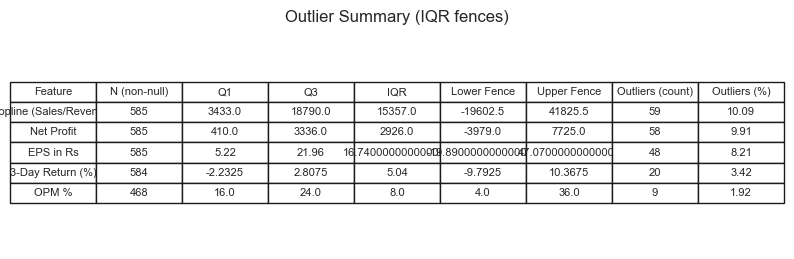

[saved] cell_8\table_outlier_summary_iqr.png


,Company,Ticker,Sector,Cap Category,Period,Result Date,"Movement Label (1,0)",value,z,z_robust
571,Bosch India,BOSCHLTD,Auto,Small,Jun 2025,2025-08-04 00:00:00,0.000000,378.180000,10.721422,29.629358
564,Bosch India,BOSCHLTD,Auto,Small,Sep 2023,2023-11-09 00:00:00,0.000000,338.680000,9.537682,26.427105
566,Bosch India,BOSCHLTD,Auto,Small,Mar 2024,2025-05-24 00:00:00,0.000000,191.400000,5.123980,14.487157
570,Bosch India,BOSCHLTD,Auto,Small,Mar 2025,2025-05-27 00:00:00,0.000000,187.740000,5.014297,14.190442
568,Bosch India,BOSCHLTD,Auto,Small,Sep 2024,2024-11-12 00:00:00,1.000000,181.700000,4.833290,13.700781
565,Bosch India,BOSCHLTD,Auto,Small,Dec 2023,2024-02-13 00:00:00,1.000000,175.670000,4.652582,13.211931
567,Bosch India,BOSCHLTD,Auto,Small,Jun 2024,2024-08-06 00:00:00,0.000000,157.830000,4.117951,11.765647
569,Bosch India,BOSCHLTD,Auto,Small,Dec 2024,2025-01-28 00:00:00,0.000000,155.360000,4.043930,11.565405
563,Bosch India,BOSCHLTD,Auto,Small,Jun 2023,2023-07-31 00:00:00,0.000000,138.670000,3.543763,10.212352
562,Bosch India,BOSCHLTD,Auto,Small,Mar 2023,2023-05-10 00:00:00,0.000000,135.280000,3.442171,9.937525


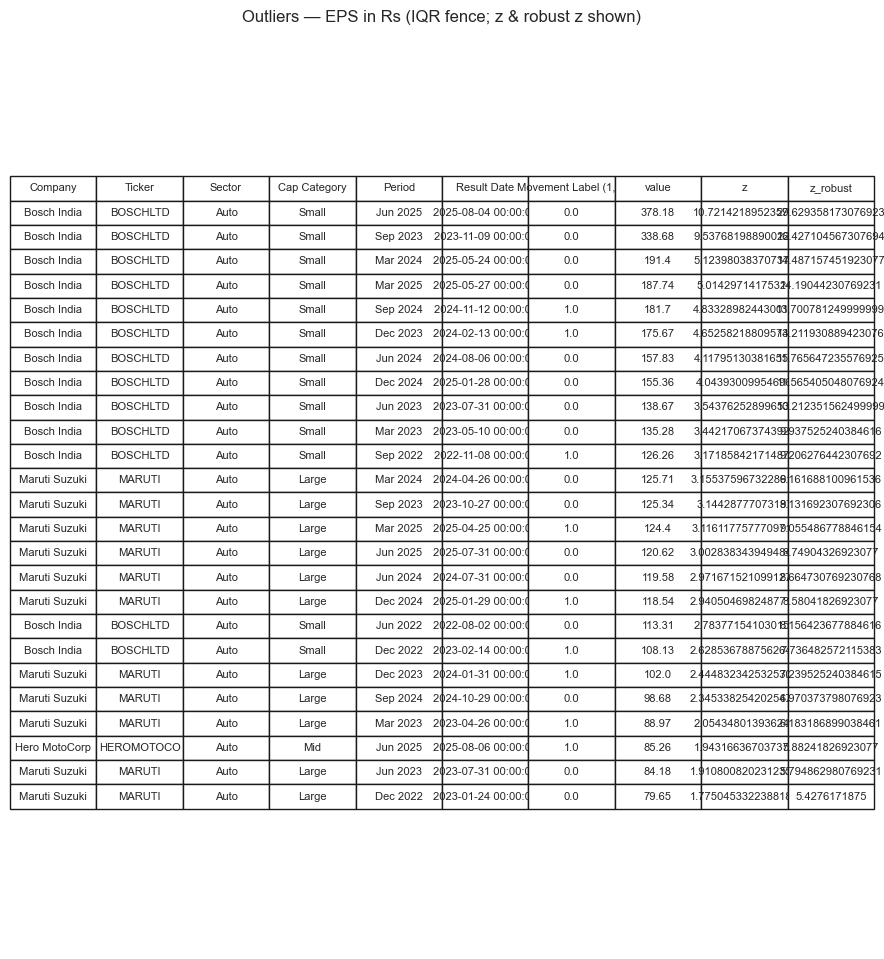

[saved] cell_8\table_outliers_EPS_in_Rs.png


,Company,Ticker,Sector,Cap Category,Period,Result Date,"Movement Label (1,0)",value,z,z_robust
449,Glenmark,GLENMARK,Pharma,Small,Dec 2023,2024-02-14 00:00:00,1.000000,-8.320000,-4.382048,-4.775460
251,ITC,ITC,FMCG,Large,Jun 2023,2023-08-14 00:00:00,0.000000,39.000000,2.816165,3.203875
249,ITC,ITC,FMCG,Large,Dec 2022,2023-02-03 00:00:00,0.000000,38.000000,2.664047,3.035250
250,ITC,ITC,FMCG,Large,Mar 2023,2023-05-18 00:00:00,1.000000,38.000000,2.664047,3.035250
455,Divis Labs,DIVISLAB,Pharma,Small,Jun 2022,2022-08-12 00:00:00,0.000000,38.000000,2.664047,3.035250
248,ITC,ITC,FMCG,Large,Sep 2022,2022-10-20 00:00:00,0.000000,37.000000,2.511929,2.866625
254,ITC,ITC,FMCG,Large,Mar 2024,2024-05-23 00:00:00,0.000000,37.000000,2.511929,2.866625
255,ITC,ITC,FMCG,Large,Jun 2024,2024-08-01 00:00:00,0.000000,37.000000,2.511929,2.866625
481,Tata Motors,TATAMOTORS,Auto,Large,Jun 2022,2022-07-27 00:00:00,1.000000,3.000000,-2.660075,-2.866625


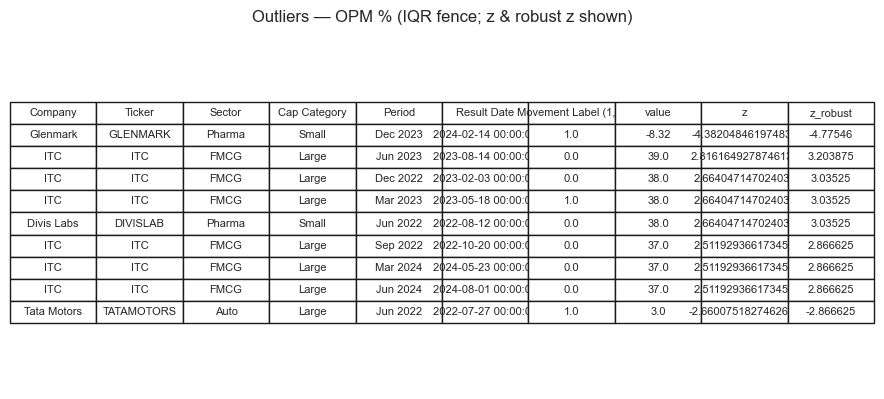

[saved] cell_8\table_outliers_OPM_.png


,Company,Ticker,Sector,Cap Category,Period,Result Date,"Movement Label (1,0)",value,z,z_robust
150,SBI,SBIN,BFSI,Large,Mar 2024,2024-05-09 00:00:00,0.000000,22203.000000,4.568391,21.902199
155,SBI,SBIN,BFSI,Large,Jun 2025,2025-08-08 00:00:00,1.000000,22121.000000,4.549125,21.817758
152,SBI,SBIN,BFSI,Large,Sep 2024,2024-11-08 00:00:00,0.000000,20565.000000,4.183543,20.215434
154,SBI,SBIN,BFSI,Large,Mar 2025,2025-05-03 00:00:00,0.000000,20379.000000,4.139842,20.023897
151,SBI,SBIN,BFSI,Large,Jun 2024,2024-08-03 00:00:00,0.000000,20094.000000,4.072881,19.730412
258,ITC,ITC,FMCG,Large,Mar 2025,2025-05-22 00:00:00,1.000000,19808.000000,4.005685,19.435898
153,SBI,SBIN,BFSI,Large,Dec 2024,2025-02-06 00:00:00,0.000000,19484.000000,3.929562,19.102252
128,HDFC Bank,HDFCBANK,BFSI,Large,Mar 2025,2025-04-19 00:00:00,1.000000,19285.000000,3.882806,18.897327
147,SBI,SBIN,BFSI,Large,Jun 2023,2023-08-04 00:00:00,0.000000,19094.000000,3.837931,18.700641
146,SBI,SBIN,BFSI,Large,Mar 2023,2023-05-18 00:00:00,0.000000,18769.000000,3.761572,18.365966


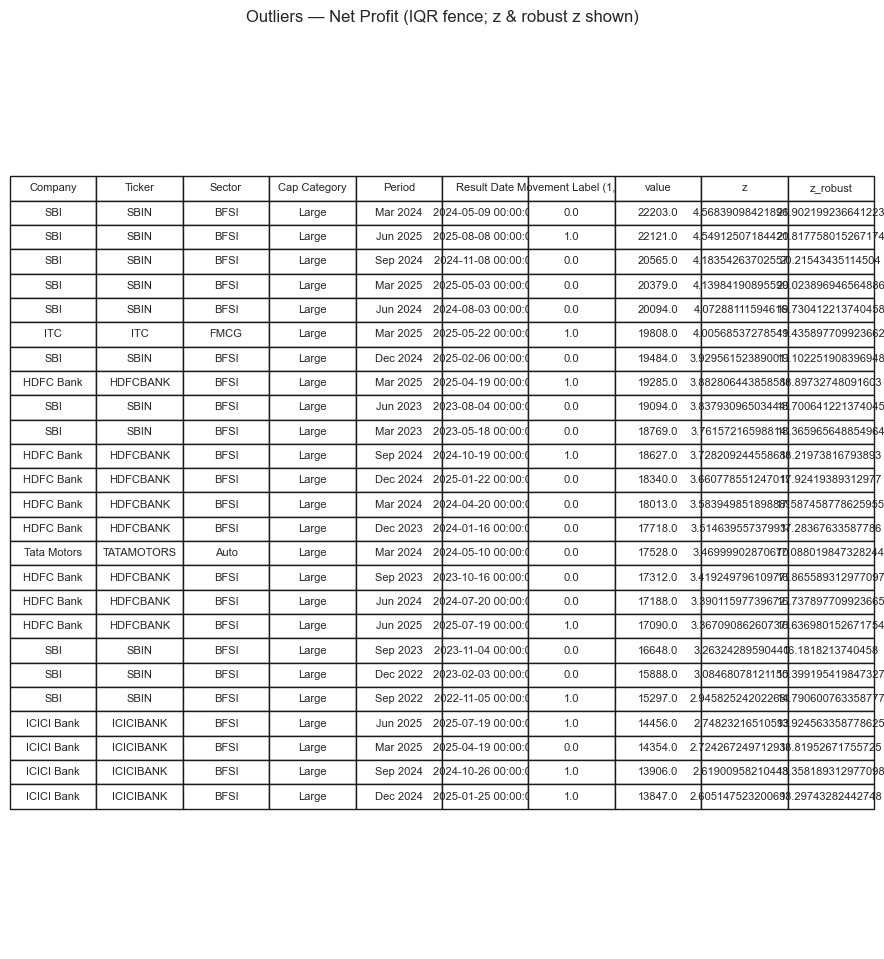

[saved] cell_8\table_outliers_Net_Profit.png


,Company,Ticker,Sector,Cap Category,Period,Result Date,"Movement Label (1,0)",value,z,z_robust
154,SBI,SBIN,BFSI,Large,Mar 2025,2025-05-03 00:00:00,0.000000,126997.000000,4.444658,15.159238
155,SBI,SBIN,BFSI,Large,Jun 2025,2025-08-08 00:00:00,1.000000,125729.000000,4.393131,14.997653
153,SBI,SBIN,BFSI,Large,Dec 2024,2025-02-06 00:00:00,0.000000,124654.000000,4.349448,14.860664
152,SBI,SBIN,BFSI,Large,Sep 2024,2024-11-08 00:00:00,0.000000,121045.000000,4.202793,14.400760
492,Tata Motors,TATAMOTORS,Auto,Large,Mar 2025,2025-05-13 00:00:00,1.000000,119503.000000,4.140132,14.204259
488,Tata Motors,TATAMOTORS,Auto,Large,Mar 2024,2024-05-10 00:00:00,0.000000,119033.000000,4.121033,14.144366
151,SBI,SBIN,BFSI,Large,Jun 2024,2024-08-03 00:00:00,0.000000,118242.000000,4.088890,14.043567
150,SBI,SBIN,BFSI,Large,Mar 2024,2024-05-09 00:00:00,0.000000,117469.000000,4.057479,13.945061
149,SBI,SBIN,BFSI,Large,Dec 2023,2024-02-03 00:00:00,1.000000,112868.000000,3.870513,13.358745
491,Tata Motors,TATAMOTORS,Auto,Large,Dec 2024,2025-01-29 00:00:00,0.000000,112608.000000,3.859948,13.325612


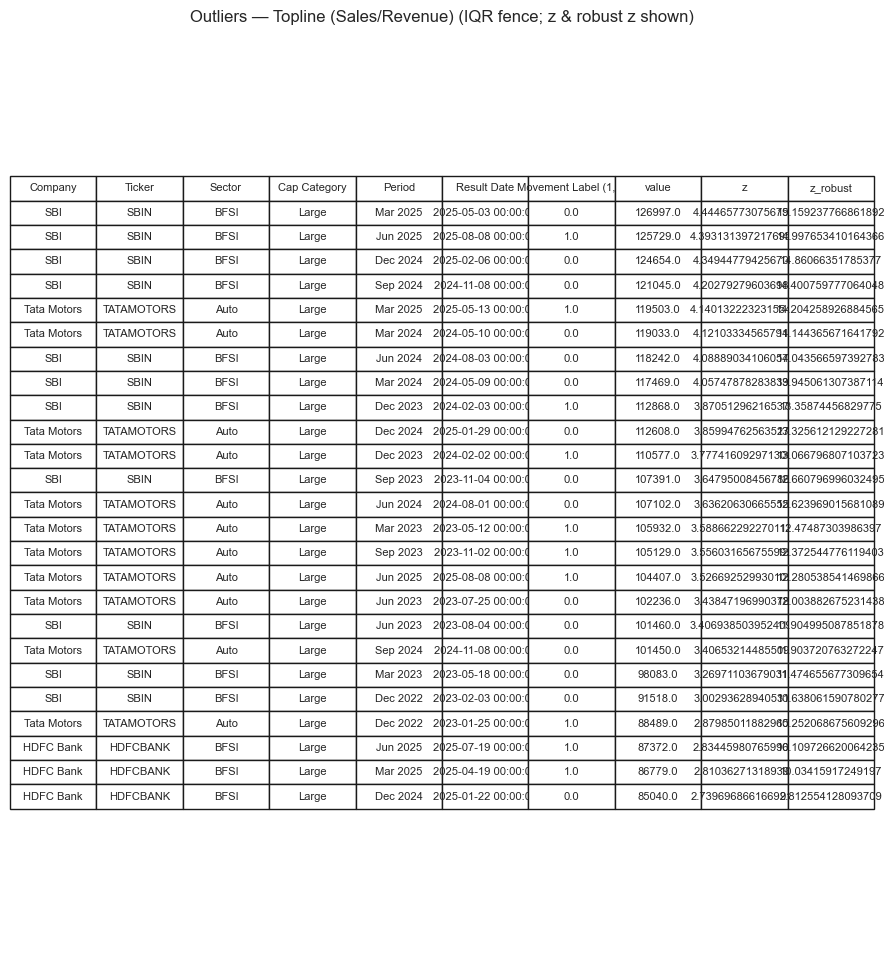

[saved] cell_8\table_outliers_Topline_Sales_Revenue_.png


,Company,Ticker,Sector,Cap Category,Period,Result Date,"Movement Label (1,0)",value,z,z_robust
332,Emami,EMAMILTD,FMCG,Small,Mar 2024,2024-05-29 00:00:00,1.000000,19.080000,4.390917,4.958557
107,Zensar Tech,ZENSARTECH,IT / Technology,Small,Mar 2023,2023-05-11 00:00:00,1.000000,15.530000,3.561182,4.028664
195,IDFC First Bank,IDFCFIRSTB,BFSI,Small,Jun 2022,2022-07-30 00:00:00,1.000000,14.070000,3.219939,3.646229
229,LIC Housing Finance,LICHSGFIN,BFSI,Small,Jun 2024,2024-02-08 00:00:00,0.000000,-12.010000,-2.875687,-3.185212
182,Bajaj Finance,BAJFINANCE,BFSI,Mid,Jun 2022,2022-07-27 00:00:00,1.000000,12.290000,2.803904,3.179973
581,Bajaj Auto Ltd,BAJAJ AUTO,Auto,Small,2024-09-01 00:00:00,2024-10-16 00:00:00,0.000000,-11.960000,-2.864000,-3.172115
214,AU Small Finance Bank,AUBANK,BFSI,Small,Dec 2023,2024-01-25 00:00:00,0.000000,-11.080000,-2.658320,-2.941606
450,Glenmark,GLENMARK,Pharma,Small,Mar 2024,2024-05-24 00:00:00,1.000000,11.330000,2.579525,2.928509
85,Coforge,COFORGE,IT / Technology,Small,Mar 2024,2024-05-02 00:00:00,0.000000,-10.980000,-2.634947,-2.915412
123,HDFC Bank,HDFCBANK,BFSI,Large,Dec 2023,2024-01-16 00:00:00,0.000000,-10.780000,-2.588201,-2.863023


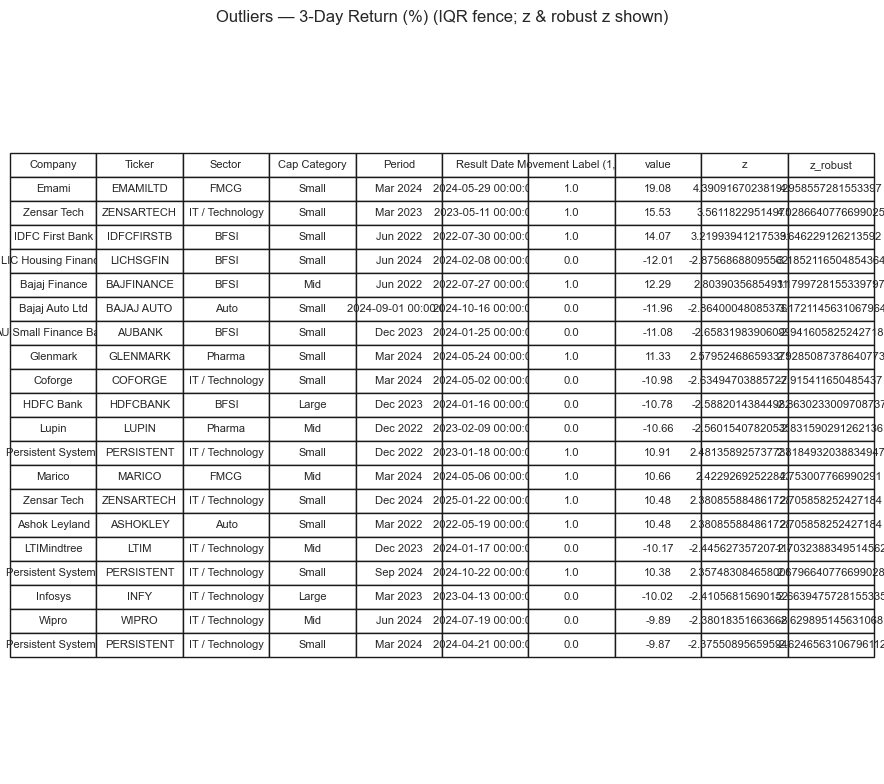

[saved] cell_8\table_outliers_3-Day_Return_.png


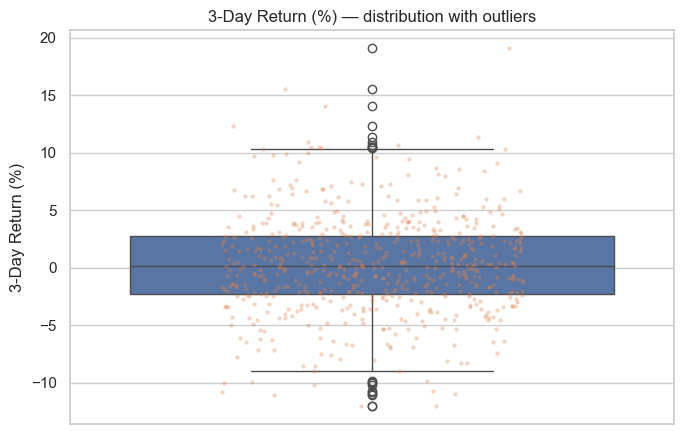

[saved] cell_8\box_3-Day_Return_.png


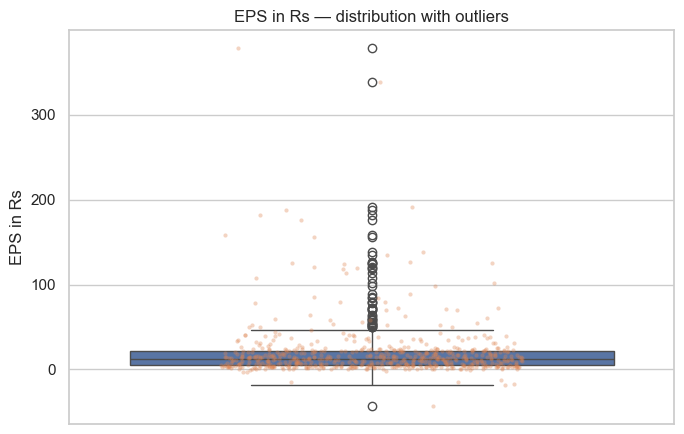

[saved] cell_8\box_EPS_in_Rs.png


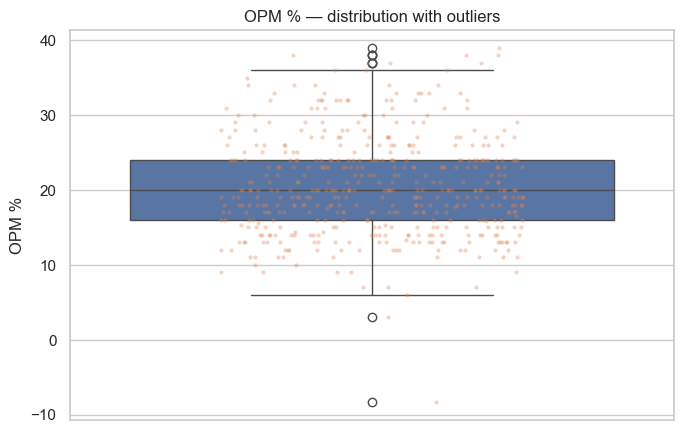

[saved] cell_8\box_OPM_.png


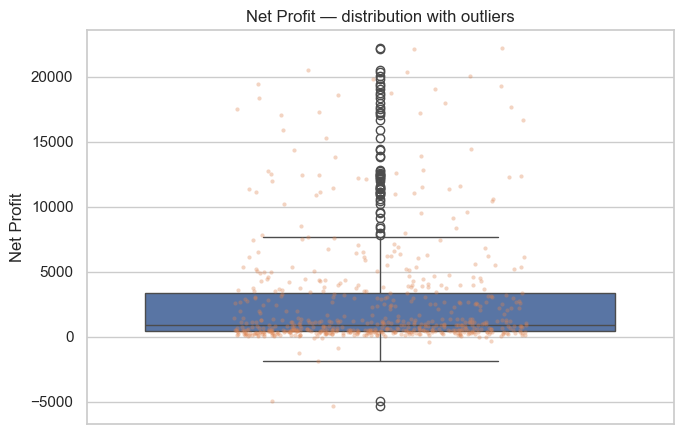

[saved] cell_8\box_Net_Profit.png


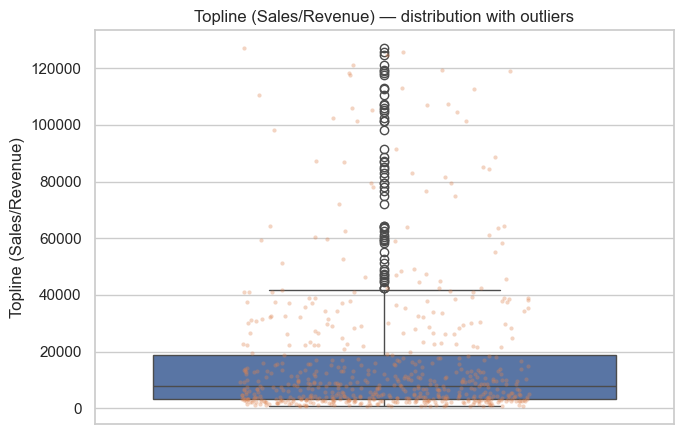

[saved] cell_8\box_Topline_Sales_Revenue_.png


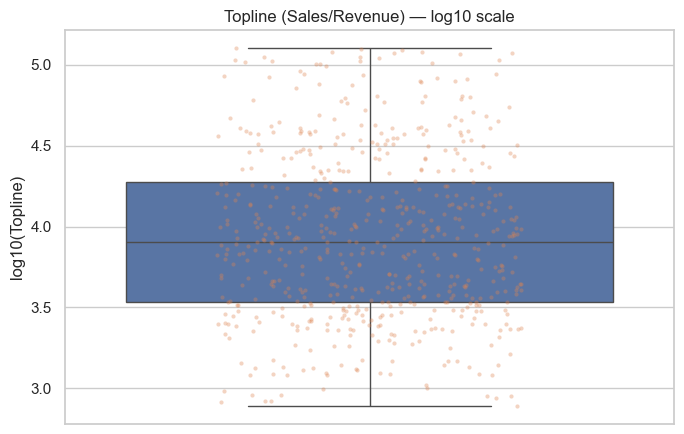

[saved] cell_8\box_topline_log10.png


,Company,Ticker,Sector,Cap Category,Period,Result Date,Closing Price (T),Closing Price (T+1),Closing Price (T+2),Closing Price (T+3),EPS in Rs,OPM %,Net Profit,Sales,Revenue,3-Day Return (%),"Movement Label (1,0)"
332,Emami,EMAMILTD,FMCG,Small,Mar 2024,2024-05-29 00:00:00,523.850000,611.850000,625.500000,634.100000,3.410000,24.000000,147.000000,891.000000,nan,19.080000,1.000000
107,Zensar Tech,ZENSARTECH,IT / Technology,Small,Mar 2023,2023-05-11 00:00:00,310.250000,339.500000,384.150000,351.650000,5.270000,14.000000,119.000000,1213.000000,nan,15.530000,1.000000
195,IDFC First Bank,IDFCFIRSTB,BFSI,Small,Jun 2022,2022-07-30 00:00:00,37.550000,41.950000,43.400000,43.150000,0.780000,nan,485.000000,nan,4922.000000,14.070000,1.000000
182,Bajaj Finance,BAJFINANCE,BFSI,Mid,Jun 2022,2022-07-27 00:00:00,6396.350000,7076.600000,7209.100000,7261.000000,4.290000,nan,2596.000000,nan,9284.000000,12.290000,1.000000
229,LIC Housing Finance,LICHSGFIN,BFSI,Small,Jun 2024,2024-02-08 00:00:00,748.450000,686.000000,652.500000,637.200000,23.750000,nan,1306.000000,nan,6797.000000,-12.010000,0.000000
581,Bajaj Auto Ltd,BAJAJ AUTO,Auto,Small,2024-09-01 00:00:00,2024-10-16 00:00:00,11616.950000,10119.450000,10063.950000,10500.500000,49.610000,16.000000,1385.000000,13247.000000,nan,-11.960000,0.000000
450,Glenmark,GLENMARK,Pharma,Small,Mar 2024,2024-05-24 00:00:00,1036.000000,1119.450000,1160.200000,1180.400000,-43.170000,16.470000,-1214.270000,3062.960000,nan,11.330000,1.000000
214,AU Small Finance Bank,AUBANK,BFSI,Small,Dec 2023,2024-01-25 00:00:00,707.850000,626.350000,625.250000,636.600000,5.610000,nan,375.000000,nan,2736.000000,-11.080000,0.000000
85,Coforge,COFORGE,IT / Technology,Small,Mar 2024,2024-05-02 00:00:00,4985.700000,4482.550000,4413.050000,4419.150000,7.240000,17.000000,229.000000,2318.000000,nan,-10.980000,0.000000
93,Persistent Systems,PERSISTENT,IT / Technology,Small,Dec 2022,2023-01-18 00:00:00,3959.600000,4258.150000,4323.500000,4593.150000,15.560000,19.000000,238.000000,2169.000000,nan,10.910000,1.000000


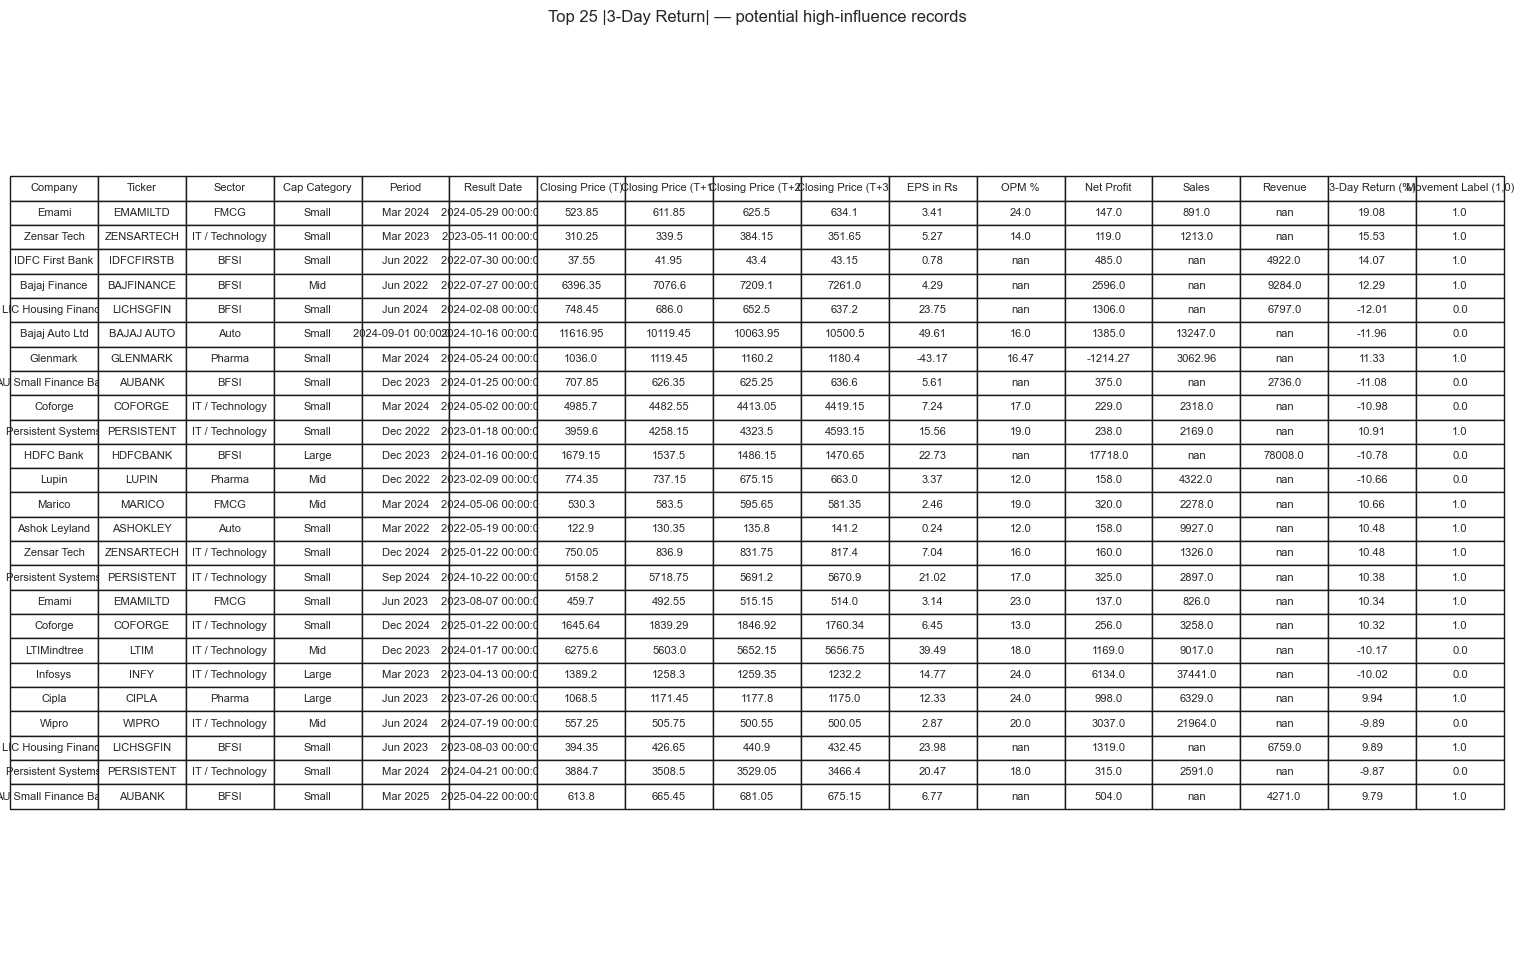

[saved] cell_8\table_top_influencers_abs_return.png

[Cell 8 complete — outlier tables & charts saved to ./cell_8/ and displayed inline]


In [46]:
import re
from IPython.display import display

sns.set_theme(style="whitegrid")

# -------------------------------------------------
# Output folder + helpers (save AND display)
# -------------------------------------------------
OUTDIR = Path("cell_8")
OUTDIR.mkdir(parents=True, exist_ok=True)

def _safe_name(s: str) -> str:
    """Make a filename safe across OS: keep letters, numbers, dot, dash, underscore."""
    name = re.sub(r"[^A-Za-z0-9._-]+", "_", s)
    name = re.sub(r"_+", "_", name).strip("_")
    return name or "figure"

def save_and_show_fig(fig, filename: str, dpi: int = 220):
    """Save figure to OUTDIR and also display it inline."""
    fname = OUTDIR / _safe_name(filename)
    fig.tight_layout()
    fig.savefig(fname, dpi=dpi, bbox_inches="tight")
    plt.show()  # display inline
    plt.close(fig)
    print(f"[saved] {fname}")

def save_and_show_df_as_image(df_in: pd.DataFrame, filename: str, title: str = None,
                              max_rows: int | None = None, fontsize: int = 9):
    """Render a DataFrame as a matplotlib table, save and display inline."""
    dfx = df_in.copy()
    if max_rows is not None and len(dfx) > max_rows:
        dfx = dfx.head(max_rows)
    n_rows, n_cols = dfx.shape
    col_w = 1.1 if n_cols <= 6 else 0.9
    row_h = 0.35
    w = max(6, min(22, n_cols * col_w))
    h = max(2.5, min(18, 1.0 + n_rows * row_h))
    fig, ax = plt.subplots(figsize=(w, h))
    ax.axis("off")
    if title:
        ax.set_title(title, pad=10)
    tbl = ax.table(
        cellText=dfx.values,
        colLabels=dfx.columns,
        loc="center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.scale(1, 1.2)
    save_and_show_fig(fig, filename)

# -------------------------------------------------
# Columns (as in your clean_data)
# -------------------------------------------------
COL_COMP  = "Company"
COL_TICK  = "Ticker"
COL_SECT  = "Sector"
COL_CAP   = "Cap Category"
COL_PER   = "Period"
COL_RDATE = "Result Date"
COL_MOVE  = "Movement Label (1,0)"

COL_EPS   = "EPS in Rs"
COL_OPM   = "OPM %"
COL_NP    = "Net Profit"
COL_SALES = "Sales"
COL_REV   = "Revenue"
COL_RET   = "3-Day Return (%)"

# Unified topline (Sales preferred, else Revenue)
df = df.copy()
df["_Topline"] = pd.to_numeric(df[COL_SALES], errors="coerce")
rev_num = pd.to_numeric(df[COL_REV], errors="coerce")
df.loc[df["_Topline"].isna(), "_Topline"] = rev_num

# Numeric casts
df["_EPS"]     = pd.to_numeric(df[COL_EPS], errors="coerce")
df["_OPM"]     = pd.to_numeric(df[COL_OPM], errors="coerce")
df["_NP"]      = pd.to_numeric(df[COL_NP], errors="coerce")
df["_RET"]     = pd.to_numeric(df[COL_RET], errors="coerce")
df["_Topline"] = pd.to_numeric(df["_Topline"], errors="coerce")

FEATURES = {
    "EPS in Rs":                  "_EPS",
    "OPM %":                      "_OPM",
    "Net Profit":                 "_NP",
    "Topline (Sales/Revenue)":    "_Topline",
    "3-Day Return (%)":           "_RET",
}

# -------------------------------------------------
# Helpers: IQR fences & z/robust z
# -------------------------------------------------
def iqr_bounds(s: pd.Series, whisker: float = 1.5):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.empty:
        return np.nan, np.nan, np.nan, np.nan, np.nan
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - whisker * iqr
    hi  = q3 + whisker * iqr
    return q1, q3, iqr, lo, hi

def add_scores(s: pd.Series):
    x = pd.to_numeric(s, errors="coerce")
    mu = x.mean()
    sd = x.std(ddof=1)
    z  = (x - mu) / sd if sd and not np.isnan(sd) and sd != 0 else pd.Series(index=x.index, dtype=float)
    med = x.median()
    mad = (x - med).abs().median()
    zm  = 0.6745 * (x - med) / mad if mad and not np.isnan(mad) and mad != 0 else pd.Series(index=x.index, dtype=float)
    return z, zm

# -------------------------------------------------
# Outlier summary (IQR) + tables per feature
# -------------------------------------------------
summary_rows = []
detail_tables = {}

for pretty, col in FEATURES.items():
    s = df[col]
    q1, q3, iqr, lo, hi = iqr_bounds(s)
    is_out = (s < lo) | (s > hi)
    n_out = int(is_out.sum())
    n_tot = int(s.notna().sum())
    pct   = (100.0 * n_out / n_tot) if n_tot else 0.0
    summary_rows.append({
        "Feature": pretty,
        "N (non-null)": n_tot,
        "Q1": q1, "Q3": q3, "IQR": iqr,
        "Lower Fence": lo, "Upper Fence": hi,
        "Outliers (count)": n_out,
        "Outliers (%)": round(pct, 2),
    })

    # detailed top outliers by robust z (|zm|), fall back to z if needed
    z, zm = add_scores(s)
    ranker = zm.copy()
    if ranker.isna().all():
        ranker = z.copy()
    det = df.loc[is_out, [COL_COMP, COL_TICK, COL_SECT, COL_CAP, COL_PER, COL_RDATE, COL_MOVE]].copy()
    det["value"] = s[is_out]
    det["z"] = z[is_out]
    det["z_robust"] = zm[is_out]
    det["abs_rank"] = ranker[is_out].abs()
    det = det.sort_values("abs_rank", ascending=False).drop(columns=["abs_rank"])
    detail_tables[pretty] = det

# Summary table — save AND show
out_summary = pd.DataFrame(summary_rows).sort_values("Outliers (count)", ascending=False)
out_summary.to_csv(OUTDIR / "outlier_summary_iqr.csv", index=False)
display(out_summary.style.format(precision=3).set_caption("Outlier Summary (IQR fences)"))
save_and_show_df_as_image(out_summary, "table_outlier_summary_iqr.png",
                          title="Outlier Summary (IQR fences)", fontsize=8)

# Detailed tables per feature — save AND show (top 25)
for pretty, det in detail_tables.items():
    safe = pretty.lower().replace("%","pct").replace(" ","_")
    det.to_csv(OUTDIR / f"outliers_{_safe_name(safe)}.csv", index=False)
    display(det.head(25).style.set_caption(f"Outliers — {pretty} (top 25 by robust z)"))
    save_and_show_df_as_image(det.head(25),
                              f"table_outliers_{pretty}.png",
                              title=f"Outliers — {pretty} (IQR fence; z & robust z shown)",
                              max_rows=25, fontsize=8)

# -------------------------------------------------
# Boxplots with jittered points (save AND show)
# -------------------------------------------------
def boxplot_with_strip(series_name, col, ylim=None):
    data = pd.DataFrame({series_name: df[col]}).dropna()
    if data.empty:
        print(f"[skip] No data for {series_name}")
        return
    fig, ax = plt.subplots(figsize=(7, 4.5))
    sns.boxplot(x=np.zeros(len(data)), y=series_name, data=data, ax=ax)
    sns.stripplot(x=np.zeros(len(data)), y=series_name, data=data, ax=ax, alpha=0.35, size=3, jitter=0.25)
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.set_title(f"{series_name} — distribution with outliers")
    if ylim is not None:
        ax.set_ylim(ylim)
    save_and_show_fig(fig, f"box_{series_name}.png")

boxplot_with_strip("3-Day Return (%)", "_RET", ylim=None)
boxplot_with_strip("EPS in Rs", "_EPS", ylim=None)
boxplot_with_strip("OPM %", "_OPM", ylim=None)
boxplot_with_strip("Net Profit", "_NP", ylim=None)

# Topline often spans orders of magnitude — show both linear and log versions
top_ok = df["_Topline"].dropna()
if not top_ok.empty and (top_ok > 0).any():
    boxplot_with_strip("Topline (Sales/Revenue)", "_Topline", ylim=None)
    lin = pd.DataFrame({"Topline": top_ok[top_ok > 0]})
    fig, ax = plt.subplots(figsize=(7, 4.5))
    sns.boxplot(x=np.zeros(len(lin)), y=np.log10(lin["Topline"]), ax=ax)
    sns.stripplot(x=np.zeros(len(lin)), y=np.log10(lin["Topline"]), ax=ax, alpha=0.35, size=3, jitter=0.25)
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.set_ylabel("log10(Topline)")
    ax.set_title("Topline (Sales/Revenue) — log10 scale")
    save_and_show_fig(fig, "box_topline_log10.png")
else:
    print("[note] Topline has no positive values to log-scale, skipping log boxplot.")

# -------------------------------------------------
# Influence scan: largest absolute 3-Day Return
# -------------------------------------------------
influence_cols = [
    COL_COMP, COL_TICK, COL_SECT, COL_CAP, COL_PER, COL_RDATE,
    "Closing Price (T)", "Closing Price (T+1)", "Closing Price (T+2)", "Closing Price (T+3)",
    COL_EPS, COL_OPM, COL_NP, COL_SALES, COL_REV, COL_RET, COL_MOVE
]

ret_order = df.assign(_abs_ret=df["_RET"].abs()).sort_values("_abs_ret", ascending=False)
top_influencers = ret_order[influence_cols].head(25).copy()
top_influencers.to_csv(OUTDIR / "top_influencers_abs_return.csv", index=False)

# show AND save table image
display(top_influencers.style.set_caption("Top 25 |3-Day Return| — potential high-influence records"))
save_and_show_df_as_image(top_influencers,
                          "table_top_influencers_abs_return.png",
                          title="Top 25 |3-Day Return| — potential high-influence records",
                          max_rows=25, fontsize=8)

print("\n[Cell 8 complete — outlier tables & charts saved to ./cell_8/ and displayed inline]")


# ==== Sector-specific panels & contrasts ====

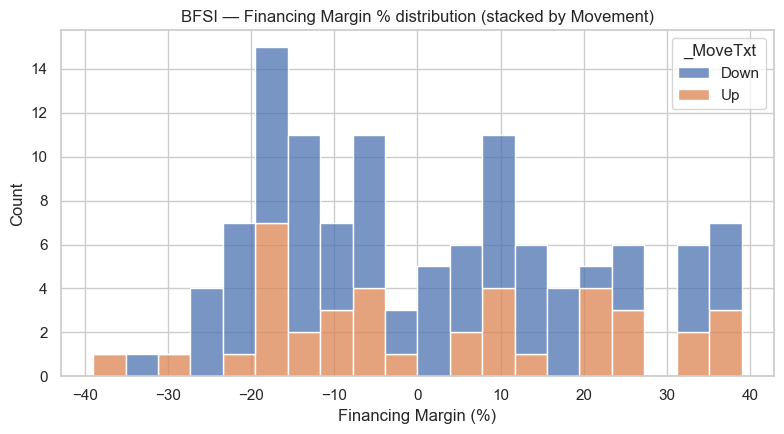

[saved] cell_9\bfsi_fin_margin_hist.png


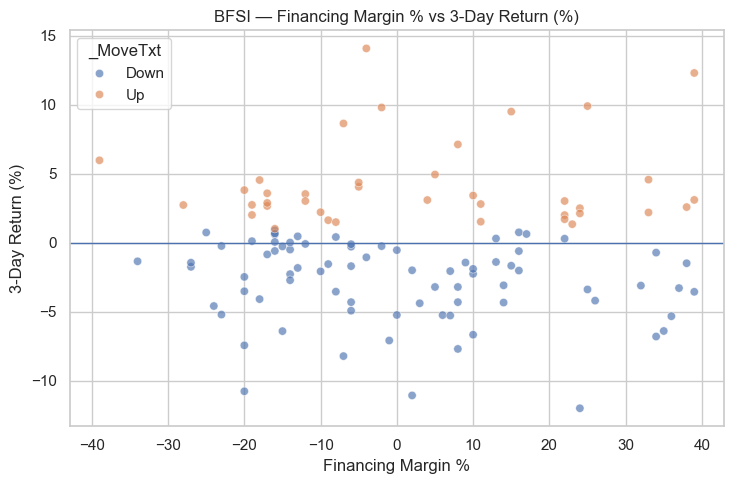

[saved] cell_9\bfsi_fin_margin_vs_return.png


,FM Quintile,n,up_pct
0,"(-39.001, -16.0]",29,34.4828
1,"(-16.0, -7.6]",18,27.7778
2,"(-7.6, 6.6]",23,30.4348
3,"(6.6, 21.0]",23,21.7391
4,"(21.0, 39.0]",24,50.0000


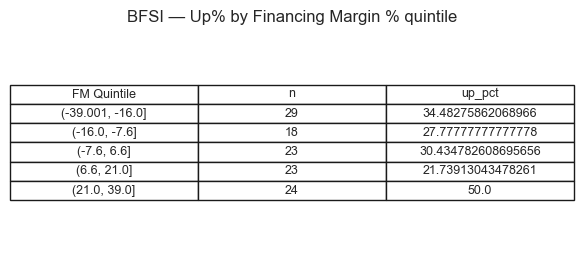

[saved] cell_9\table_bfsi_up_pct_by_fm_quintile.png


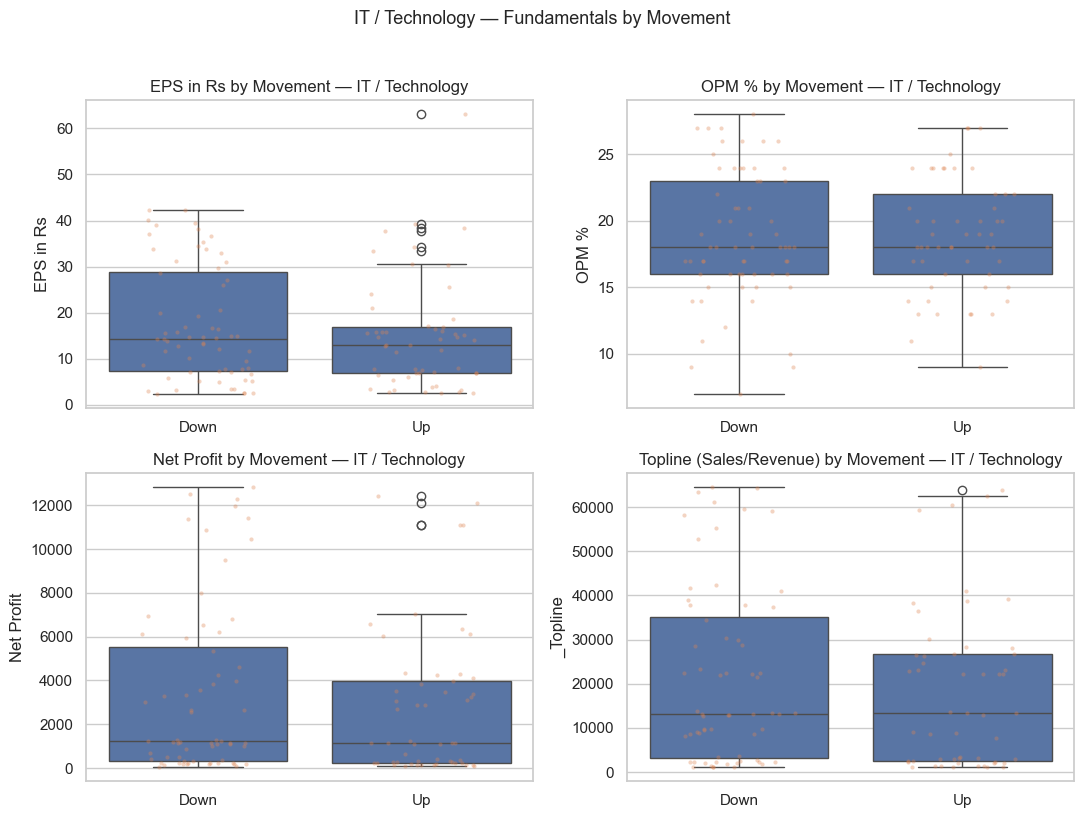

[saved] cell_9\IT_Technology_fundamentals_by_movement.png


,Sector,rows,mean_return,median_return,up_pct
0,IT / Technology,117,0.311,0.520,45.30


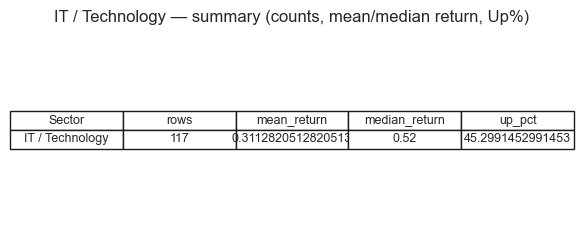

[saved] cell_9\table_sector_summary_IT_Technology.png


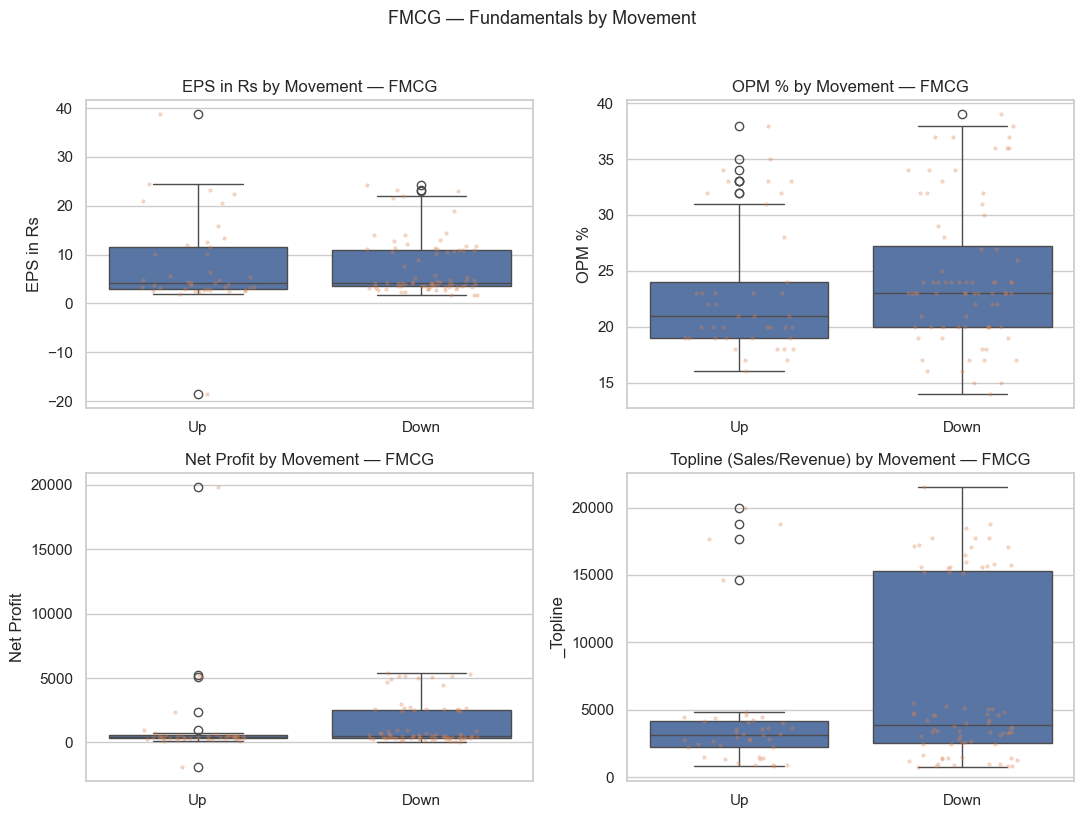

[saved] cell_9\FMCG_fundamentals_by_movement.png


,Sector,rows,mean_return,median_return,up_pct
0,FMCG,117,0.211,-0.510,35.04


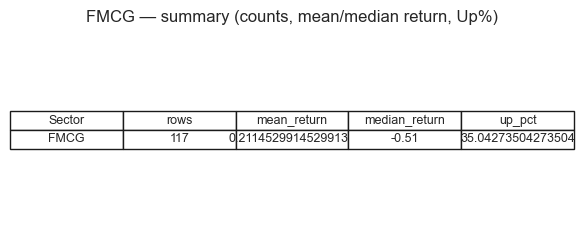

[saved] cell_9\table_sector_summary_FMCG.png


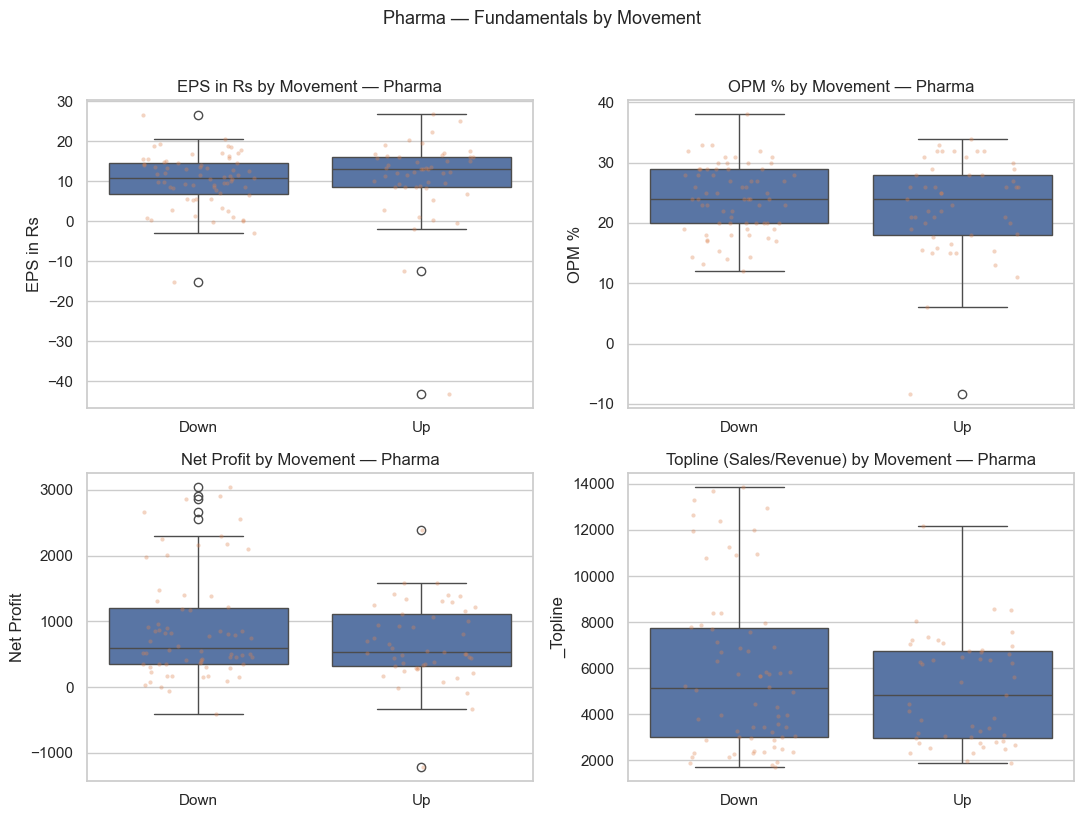

[saved] cell_9\Pharma_fundamentals_by_movement.png


,Sector,rows,mean_return,median_return,up_pct
0,Pharma,117,0.502,0.220,41.88


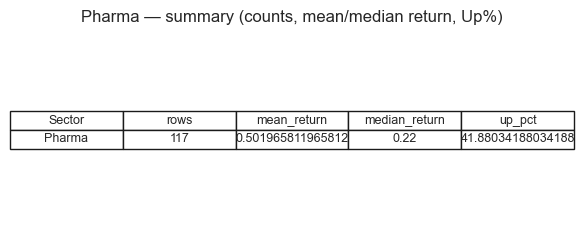

[saved] cell_9\table_sector_summary_Pharma.png


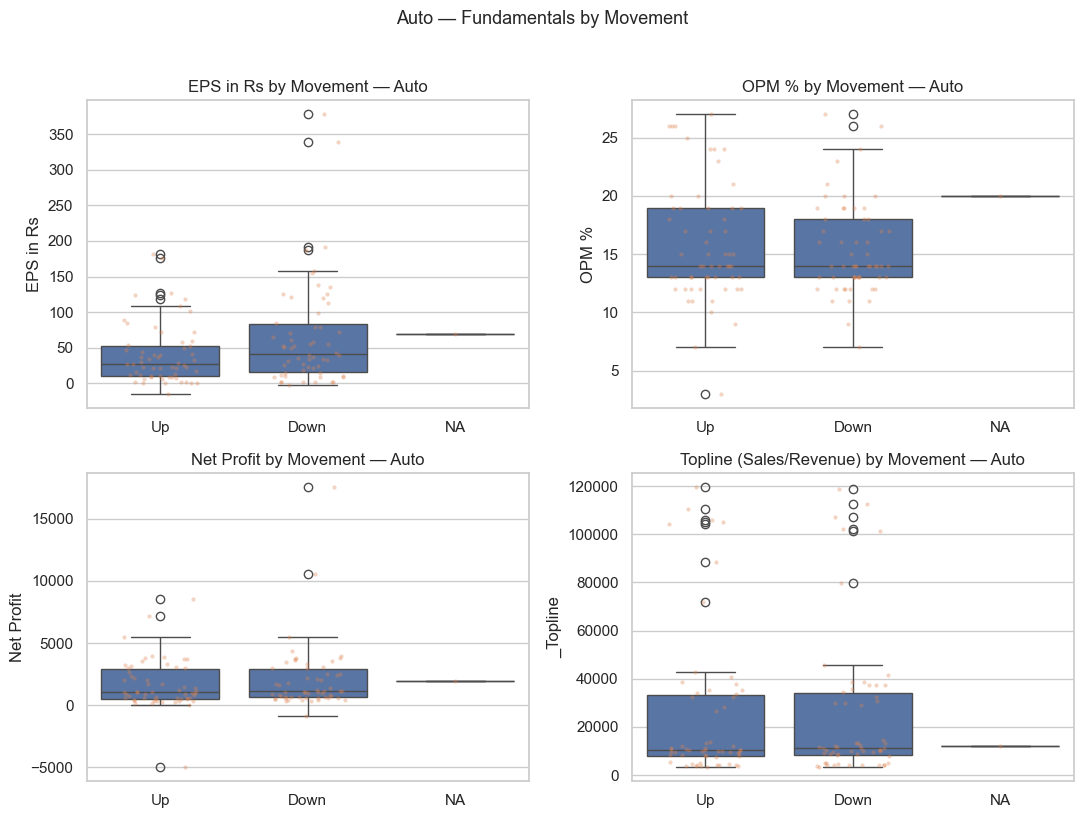

[saved] cell_9\Auto_fundamentals_by_movement.png


,Sector,rows,mean_return,median_return,up_pct
0,Auto,117,0.913,0.965,50.00


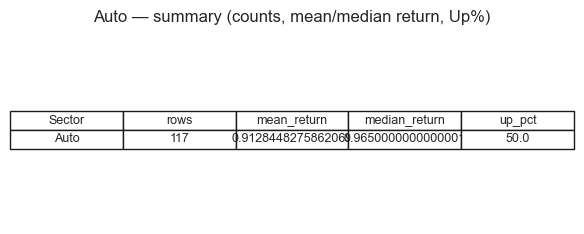

[saved] cell_9\table_sector_summary_Auto.png


,Sector,rows,mean_return,median_return,up_pct
0,Auto,117,0.913,0.965,50.000000
4,Pharma,117,0.502,0.220,41.880000
3,IT / Technology,117,0.311,0.520,45.300000
2,FMCG,117,0.211,-0.510,35.040000
1,BFSI,117,-0.464,-0.510,33.330000


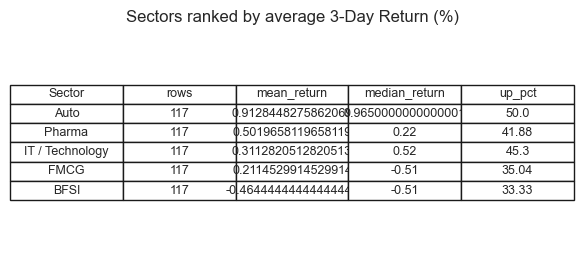

[saved] cell_9\table_sector_ranking.png


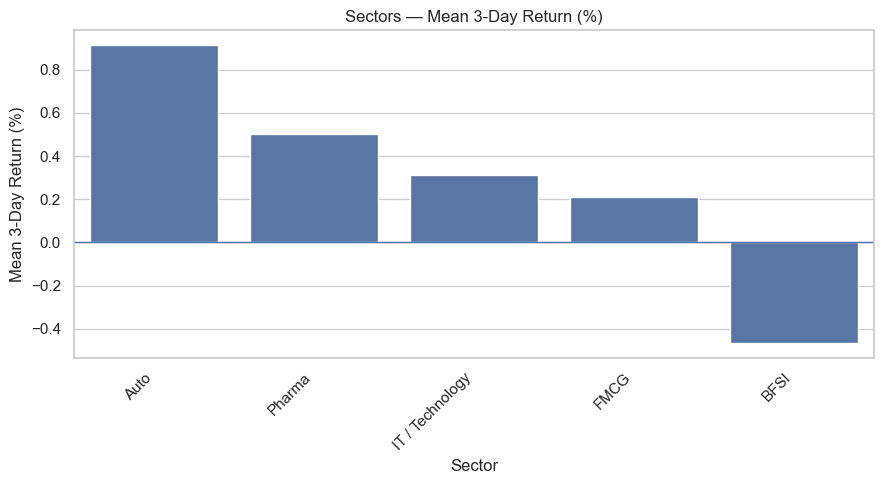

[saved] cell_9\sectors_mean_return_bar.png

[Cell 9 complete — sector panels, BFSI focus, and sector rankings saved in ./cell_9/ and shown inline]


In [50]:
# ------------------------------------------------------------------
# Output folder + helpers
# ------------------------------------------------------------------
OUTDIR = Path("cell_9")
OUTDIR.mkdir(parents=True, exist_ok=True)

def _safe_name(s: str) -> str:
    import re
    name = re.sub(r"[^A-Za-z0-9._-]+", "_", str(s))
    name = re.sub(r"_+", "_", name).strip("_")
    return name or "figure"

def save_fig(fig, filename: str, dpi: int = 220, show: bool = True):
    path = OUTDIR / _safe_name(filename)
    fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)
    print(f"[saved] {path}")

def show_df_and_save_image(dfin: pd.DataFrame, filename: str, title: str = None,
                           max_rows: int | None = 30, fontsize: int = 9):
    """Render a DataFrame as a static image (matplotlib table), save + show inline."""
    dfp = dfin.copy()
    if max_rows is not None and len(dfp) > max_rows:
        dfp = dfp.head(max_rows)

    n_rows, n_cols = dfp.shape
    col_w = 1.05 if n_cols <= 6 else 0.92
    row_h = 0.35
    w = max(6, min(22, n_cols * col_w))
    h = max(2.5, min(18, 1.0 + n_rows * row_h))

    fig, ax = plt.subplots(figsize=(w, h))
    ax.axis("off")
    if title:
        ax.set_title(title, pad=10)
    tbl = ax.table(cellText=dfp.values, colLabels=dfp.columns, cellLoc="center", loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.scale(1, 1.15)

    save_fig(fig, filename)

# ------------------------------------------------------------------
# Column aliases
# ------------------------------------------------------------------
COL_COMP  = "Company"
COL_TICK  = "Ticker"
COL_SECT  = "Sector"
COL_CAP   = "Cap Category"
COL_PER   = "Period"
COL_RDATE = "Result Date"
COL_MOVE  = "Movement Label (1,0)"
COL_RET   = "3-Day Return (%)"

COL_EPS   = "EPS in Rs"
COL_OPM   = "OPM %"
COL_NP    = "Net Profit"
COL_SALES = "Sales"
COL_REV   = "Revenue"
COL_FM    = "Financing Margin %"

# Numeric casts (safe; no mutation of source columns)
df_num = df.copy()
for c in [COL_EPS, COL_OPM, COL_NP, COL_SALES, COL_REV, COL_RET, COL_FM]:
    df_num[c] = pd.to_numeric(df_num[c], errors="coerce")

# Unified topline (Sales preferred, else Revenue)
df_num["_Topline"] = df_num[COL_SALES]
df_num.loc[df_num["_Topline"].isna(), "_Topline"] = df_num[COL_REV]
df_num["_Topline"] = pd.to_numeric(df_num["_Topline"], errors="coerce")

# Movement label to text (for nicer legends)
df_num["_MoveTxt"] = df_num[COL_MOVE].map({1: "Up", 0: "Down"}).fillna("NA")

# ==================================================================
# A) BFSI-only panel
# ==================================================================
df_bfsi = df_num[df_num[COL_SECT].str.contains("BFSI", na=False)].copy()

if not df_bfsi.empty and df_bfsi[COL_FM].notna().any():
    # Dist: Financing Margin %
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.histplot(data=df_bfsi, x=COL_FM, bins=20, hue="_MoveTxt", multiple="stack", ax=ax)
    ax.set_title("BFSI — Financing Margin % distribution (stacked by Movement)")
    ax.set_xlabel("Financing Margin (%)")
    save_fig(fig, "bfsi_fin_margin_hist.png")

    # FM% vs Return
    fig, ax = plt.subplots(figsize=(7.5, 5))
    sns.scatterplot(data=df_bfsi, x=COL_FM, y=COL_RET, hue="_MoveTxt", alpha=0.65, ax=ax)
    ax.axhline(0, linewidth=1)
    ax.set_title("BFSI — Financing Margin % vs 3-Day Return (%)")
    save_fig(fig, "bfsi_fin_margin_vs_return.png")

    # Up% by FM% quantiles
    fm_nonnull = df_bfsi[COL_FM].dropna()
    if not fm_nonnull.empty:
        qcuts = pd.qcut(fm_nonnull, q=5, duplicates="drop")
        temp = df_bfsi.loc[df_bfsi[COL_FM].notna(), [COL_FM, COL_MOVE]].copy()
        temp["FM Quintile"] = qcuts.values
        grp = temp.groupby("FM Quintile", observed=True).agg(
            n=(COL_MOVE, "size"),
            up_pct=(COL_MOVE, lambda s: 100 * s.mean())
        ).reset_index()
        display(grp)
        show_df_and_save_image(grp, "table_bfsi_up_pct_by_fm_quintile.png",
                               title="BFSI — Up% by Financing Margin % quintile", max_rows=20)
else:
    print("[note] BFSI panel skipped (no rows or Financing Margin % missing).")

# ==================================================================
# B) Sector panels for IT / FMCG / Pharma / Auto
#     Features: EPS, OPM %, Net Profit, Topline
# ==================================================================
focus_sectors = ["IT / Technology", "FMCG", "Pharma", "Auto"]
feat_defs = [
    ("EPS in Rs", COL_EPS),
    ("OPM %", COL_OPM),
    ("Net Profit", COL_NP),
    ("Topline (Sales/Revenue)", "_Topline"),
]

for sname in focus_sectors:
    dfx = df_num[df_num[COL_SECT] == sname].copy()
    if dfx.empty:
        print(f"[note] Sector panel skipped: {sname} (no rows)")
        continue

    # Grid of 2x2 boxplots by Movement label
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    axes = axes.ravel()
    for i, (pretty, col) in enumerate(feat_defs):
        sub = dfx[[col, "_MoveTxt"]].dropna()
        ax = axes[i]
        if sub.empty:
            ax.set_visible(False)
            continue
        sns.boxplot(data=sub, x="_MoveTxt", y=col, ax=ax)
        sns.stripplot(data=sub, x="_MoveTxt", y=col, ax=ax, alpha=0.35, size=3, jitter=0.25)
        ax.set_xlabel("")
        ax.set_title(f"{pretty} by Movement — {sname}")
    fig.suptitle(f"{sname} — Fundamentals by Movement", y=1.02, fontsize=13)
    save_fig(fig, f"{sname}_fundamentals_by_movement.png")

    # Sector summary table: counts, mean return, Up%
    t = pd.DataFrame({
        "Sector": [sname],
        "rows": [len(dfx)],
        "mean_return": [dfx[COL_RET].mean()],
        "median_return": [dfx[COL_RET].median()],
        "up_pct": [dfx[COL_MOVE].mean() * 100.0],
    })
    display(t.style.format({"mean_return": "{:.3f}", "median_return": "{:.3f}", "up_pct": "{:.2f}"}))
    show_df_and_save_image(
        t[["Sector", "rows", "mean_return", "median_return", "up_pct"]],
        f"table_sector_summary_{sname}.png",
        title=f"{sname} — summary (counts, mean/median return, Up%)",
        max_rows=10
    )

# ==================================================================
# C) Global sector summary / ranking
# ==================================================================
sec_summ = (
    df_num.groupby(COL_SECT, dropna=False)
          .agg(
              rows=(COL_TICK, "size"),
              mean_return=(COL_RET, "mean"),
              median_return=(COL_RET, "median"),
              up_pct=(COL_MOVE, "mean"),
          )
          .reset_index()
)
sec_summ["up_pct"] = (sec_summ["up_pct"] * 100).round(2)
sec_summ = sec_summ.sort_values("mean_return", ascending=False)

display(sec_summ.style.format({"mean_return": "{:.3f}", "median_return": "{:.3f}"}))
show_df_and_save_image(sec_summ, "table_sector_ranking.png",
                       title="Sectors ranked by average 3-Day Return (%)", max_rows=30)

# Simple bar chart for sector mean return
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=sec_summ, x=COL_SECT, y="mean_return", ax=ax)
ax.axhline(0, linewidth=1)
ax.set_xlabel("Sector")
ax.set_ylabel("Mean 3-Day Return (%)")
ax.set_title("Sectors — Mean 3-Day Return (%)")
plt.xticks(rotation=45, ha="right")
save_fig(fig, "sectors_mean_return_bar.png")

print("\n[Cell 9 complete — sector panels, BFSI focus, and sector rankings saved in ./cell_9/ and shown inline]")


# === Synthesis tables & “top features” lists ===

,feature,pearson_r
15,3-Day Return (%),1.0000
2,Operating Profit,-0.0917
9,Net Profit,-0.0752
0,Sales,-0.0734
3,OPM %,-0.0709
7,Profit before tax,-0.0673
1,Expenses,-0.0538
8,Tax %,0.0533
5,Interest,-0.0482
10,EPS in Rs,-0.0373


,feature,spearman_r
15,3-Day Return (%),1.0000
11,Revenue,0.0898
9,Net Profit,-0.0894
12,Financing Profit,-0.0865
7,Profit before tax,-0.0821
2,Operating Profit,-0.0780
5,Interest,-0.0770
3,OPM %,-0.0735
0,Sales,-0.0708
4,Other Income,-0.0583


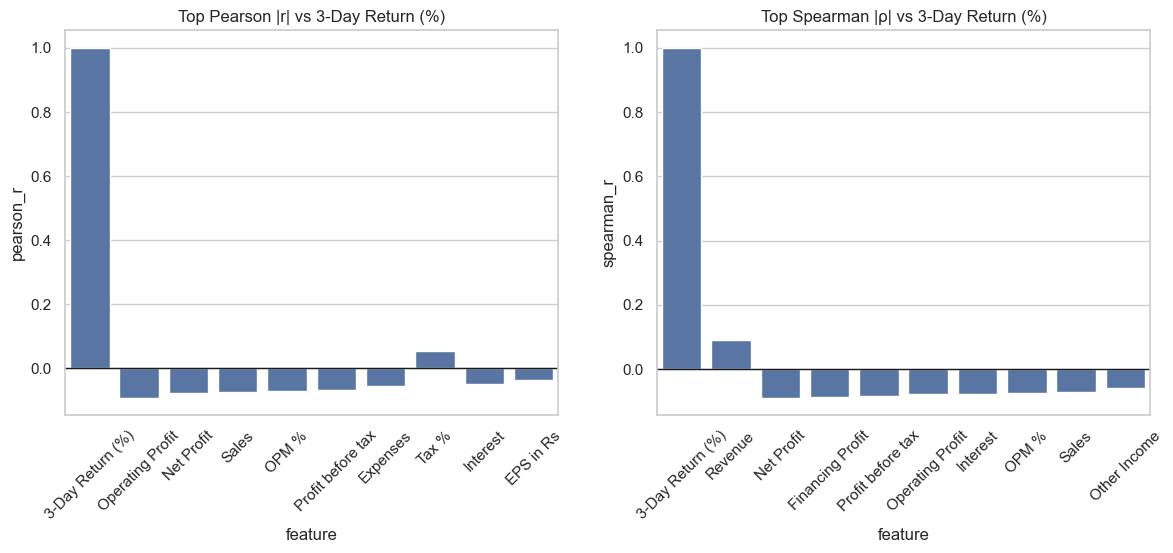

[saved] cell_10\top_correlations_vs_return.png
[saved] cell_10\tbl_top_pearson_vs_return.png
[saved] cell_10\tbl_top_spearman_vs_return.png


,feature,mutual_info
15,3-Day Return (%),0.6759
2,Operating Profit,0.0322
12,Financing Profit,0.0235
0,Sales,0.0210
11,Revenue,0.0204
6,Depreciation,0.0136
3,OPM %,0.0112
4,Other Income,0.0096
14,3-Day Avg Price Post Result,0.0061
1,Expenses,0.0056


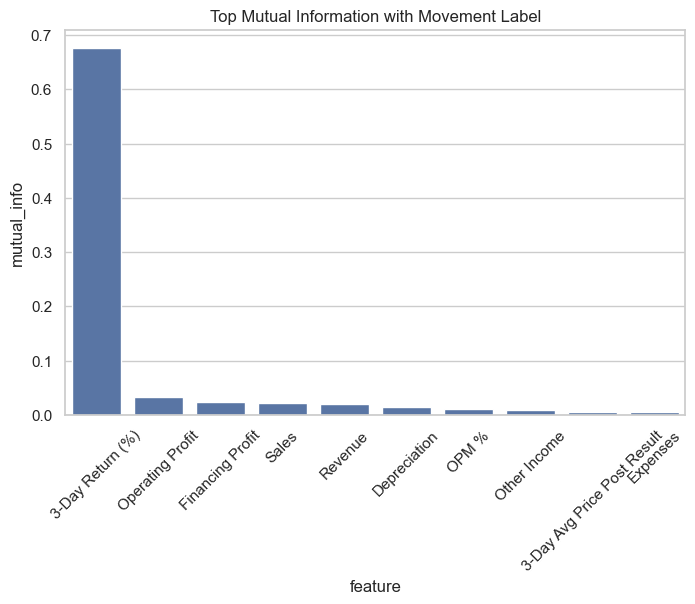

[saved] cell_10\top_mutual_info_vs_label.png
[saved] cell_10\tbl_top_mutual_info_vs_label.png


,rows,mean_return,median_return,up_pct
Sector,,,,
Auto,116,0.913,0.965,50.000000
Pharma,117,0.502,0.220,41.880000
IT / Technology,117,0.311,0.520,45.300000
FMCG,117,0.211,-0.510,35.040000
BFSI,117,-0.464,-0.510,33.330000


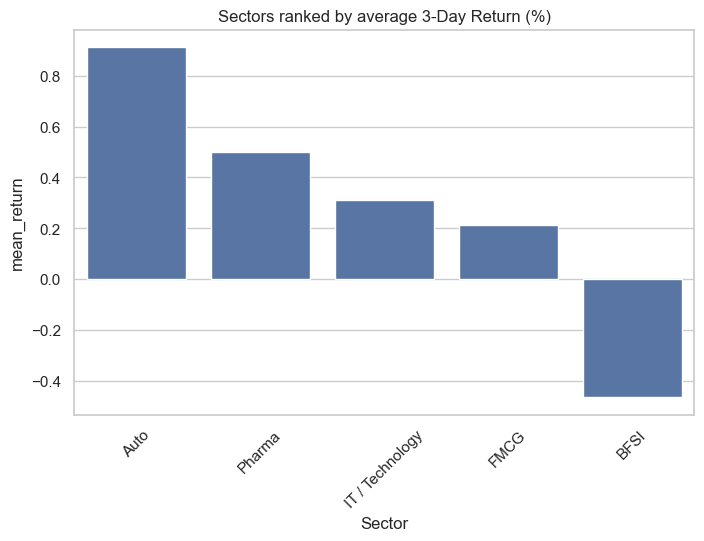

[saved] cell_10\sector_rank_mean_return.png
[saved] cell_10\tbl_sector_rank_mean_return.png


,rows,tickers,mean_return,median_return,up_pct
Cap Category,,,,,
Small,207,16,0.624,0.290,44.930000
Mid,182,14,0.313,0.130,41.760000
Large,195,15,-0.074,0.060,36.410000


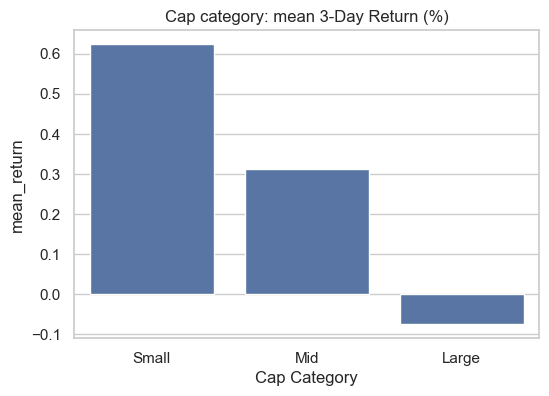

[saved] cell_10\cap_category_mean_return.png
[saved] cell_10\tbl_cap_category_mean_return.png


,feature,n_up,n_down,mean_up,mean_down,p_ttest,p_mw,cohens_d,cliffs_delta,sig_any
15,3-Day Return (%),240,344,4.207,-2.437,0.0000,0.0000,2.407,1.000,True
3,OPM %,201,266,19.785,21.020,0.0451,0.0723,-0.188,-0.097,True
9,Net Profit,240,344,2353.132,3044.392,0.0477,0.0271,-0.163,-0.107,True
7,Profit before tax,240,344,3104.536,3980.058,0.0508,0.0364,-0.161,-0.102,True
5,Interest,240,344,2672.783,4170.320,0.0993,0.1432,-0.132,-0.071,False
4,Other Income,240,344,2036.866,2840.340,0.2045,0.1150,-0.104,-0.077,False
8,Tax %,240,344,41.998,26.638,0.3544,0.5112,0.092,0.032,False
10,EPS in Rs,240,344,18.956,21.297,0.3743,0.7982,-0.070,0.012,False
6,Depreciation,240,344,465.537,395.173,0.3977,0.6295,0.074,0.023,False
2,Operating Profit,201,266,2537.456,2819.958,0.3980,0.2261,-0.079,-0.065,False


[saved] cell_10\tbl_up_vs_down_significance.png


In [54]:
from sklearn.feature_selection import mutual_info_classif
from scipy import stats

# ---- config & helpers ----
CELL_DIR = Path("cell_10"); CELL_DIR.mkdir(exist_ok=True, parents=True)

def save_fig(fig, filename, dpi=160):
    path = CELL_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    print(f"[saved] {path}")

def save_table_image(df_table: pd.DataFrame, filename: str, title:str=None, max_rows=40, fontsize=9):
    fig, ax = plt.subplots(figsize=(min(12, max(6, df_table.shape[1]*0.9)), 
                                    min(18, max(2.5, min(max_rows, len(df_table))*0.35))))
    ax.axis("off")
    if title:
        ax.set_title(title, loc="left")
    tbl = ax.table(cellText=df_table.head(max_rows).values,
                   colLabels=df_table.columns, cellLoc="left", loc="upper left")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.scale(1, 1.3)
    save_fig(fig, filename)

# ---- columns ----
COL_SECTOR = "Sector"
COL_CAP    = "Cap Category"
COL_RET    = "3-Day Return (%)"
COL_MOVE   = "Movement Label (1,0)"

# Verify required columns exist
for c in [COL_SECTOR, COL_CAP, COL_RET, COL_MOVE]:
    if c not in df.columns:
        raise ValueError(f"Required column missing: {c}")

# Numeric feature pool (drop id/date/tickers)
drop_like = {"Company","Ticker","AV_Ticker.BSE","Period","Result Date","_T_date",
             "Closing Price (T)","Closing Price (T+1)","Closing Price (T+2)","Closing Price (T+3)"}
num_cols = [c for c in df.columns 
            if (c not in drop_like) and (pd.api.types.is_numeric_dtype(df[c])) and (c != COL_MOVE)]

# ---------------------------
# 1) Top features by correlation with Return
# ---------------------------
corr_rows = []
spear_rows = []
ret_series = df[COL_RET]

for c in num_cols:
    s = df[c]
    ok = s.notna() & ret_series.notna()
    if ok.sum() < 10: 
        continue
    pr = np.corrcoef(s[ok], ret_series[ok])[0,1]
    sr, _ = stats.spearmanr(s[ok], ret_series[ok])
    corr_rows.append((c, pr))
    spear_rows.append((c, sr))

pearson_vs_ret = pd.DataFrame(corr_rows, columns=["feature","pearson_r"])\
                   .sort_values("pearson_r", key=lambda x: x.abs(), ascending=False)
spearman_vs_ret = pd.DataFrame(spear_rows, columns=["feature","spearman_r"])\
                    .sort_values("spearman_r", key=lambda x: x.abs(), ascending=False)

topN = 10
display(pearson_vs_ret.head(topN))
display(spearman_vs_ret.head(topN))

# barplots
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(data=pearson_vs_ret.head(topN), x="feature", y="pearson_r", ax=axes[0])
axes[0].axhline(0, linewidth=1, color="k")
axes[0].set_title("Top Pearson |r| vs 3-Day Return (%)")
axes[0].tick_params(axis="x", rotation=45)
sns.barplot(data=spearman_vs_ret.head(topN), x="feature", y="spearman_r", ax=axes[1])
axes[1].axhline(0, linewidth=1, color="k")
axes[1].set_title("Top Spearman |ρ| vs 3-Day Return (%)")
axes[1].tick_params(axis="x", rotation=45)
plt.show()
save_fig(fig, "top_correlations_vs_return.png")

# Save table images
save_table_image(pearson_vs_ret.head(topN).round(4), "tbl_top_pearson_vs_return.png",
                 title="Top features by Pearson correlation with 3-Day Return")
save_table_image(spearman_vs_ret.head(topN).round(4), "tbl_top_spearman_vs_return.png",
                 title="Top features by Spearman correlation with 3-Day Return")

# ---------------------------
# 2) Top features by Mutual Information with Movement Label
# ---------------------------
y = df[COL_MOVE]
mask = y.notna()
X = df.loc[mask, num_cols].copy()
y = y[mask].astype(int)

# Simple median impute for MI
X = X.apply(lambda s: s.fillna(s.median()), axis=0)

mi = mutual_info_classif(X.values, y.values, random_state=42, discrete_features=False)
mi_df = pd.DataFrame({"feature": X.columns, "mutual_info": mi})\
         .sort_values("mutual_info", ascending=False)
display(mi_df.head(topN))

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=mi_df.head(topN), x="feature", y="mutual_info", ax=ax)
ax.set_title("Top Mutual Information with Movement Label")
ax.tick_params(axis="x", rotation=45)
plt.show()
save_fig(fig, "top_mutual_info_vs_label.png")
save_table_image(mi_df.head(topN).round(4), "tbl_top_mutual_info_vs_label.png",
                 title="Top features by Mutual Information with Movement Label")

# ---------------------------
# 3) Sectors ranked by average Return
# ---------------------------
sec_rank = (
    df[[COL_SECTOR, COL_RET, COL_MOVE, "Ticker"]]
    .dropna(subset=[COL_SECTOR, COL_RET])
    .groupby(COL_SECTOR)
    .agg(
        rows=(COL_RET,"size"),
        mean_return=(COL_RET,"mean"),
        median_return=(COL_RET,"median"),
        up_pct=(COL_MOVE,"mean")
    )
    .sort_values("mean_return", ascending=False)
)
sec_rank["up_pct"] = (sec_rank["up_pct"]*100).round(2)

display(sec_rank.style.format({"mean_return":"{:.3f}","median_return":"{:.3f}"}))

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=sec_rank.reset_index(), x=COL_SECTOR, y="mean_return", ax=ax)
ax.set_title("Sectors ranked by average 3-Day Return (%)")
ax.tick_params(axis="x", rotation=45)
plt.show()
save_fig(fig, "sector_rank_mean_return.png")
save_table_image(sec_rank.reset_index().round(3), "tbl_sector_rank_mean_return.png",
                 title="Sectors ranked by average 3-Day Return (%)")

# ---------------------------
# 4) Cap category summary
# ---------------------------
cap_sum = (
    df[[COL_CAP, COL_RET, COL_MOVE, "Ticker"]]
    .dropna(subset=[COL_CAP, COL_RET])
    .groupby(COL_CAP)
    .agg(
        rows=(COL_RET,"size"),
        tickers=("Ticker", "nunique"),
        mean_return=(COL_RET, "mean"),
        median_return=(COL_RET, "median"),
        up_pct=(COL_MOVE,"mean")
    )
    .sort_values("mean_return", ascending=False)
)
cap_sum["up_pct"] = (cap_sum["up_pct"]*100).round(2)

display(cap_sum.style.format({"mean_return":"{:.3f}","median_return":"{:.3f}"}))

fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(data=cap_sum.reset_index(), x=COL_CAP, y="mean_return", ax=ax)
ax.set_title("Cap category: mean 3-Day Return (%)")
ax.tick_params(axis="x", rotation=0)
plt.show()
save_fig(fig, "cap_category_mean_return.png")
save_table_image(cap_sum.reset_index().round(3), "tbl_cap_category_mean_return.png",
                 title="Cap category summary")

# ---------------------------
# 5) Statistically significant Up vs Down differences
# ---------------------------
def cohens_d(x, y):
    x = np.asarray(x); y = np.asarray(y)
    nx, ny = len(x), len(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    pooled = ((nx-1)*vx + (ny-1)*vy) / (nx+ny-2) if (nx+ny-2)>0 else np.nan
    return (np.mean(x) - np.mean(y)) / np.sqrt(pooled) if pooled>0 else np.nan

def cliffs_delta(x, y):
    # nonparametric effect size
    x = np.asarray(x); y = np.asarray(y)
    n1, n2 = len(x), len(y)
    # rank approach
    gt = sum(a > b for a in x for b in y)
    lt = sum(a < b for a in x for b in y)
    return (gt - lt) / (n1 * n2) if (n1>0 and n2>0) else np.nan

rows = []
xy = df[[COL_MOVE] + num_cols].dropna(subset=[COL_MOVE]).copy()
xy[COL_MOVE] = xy[COL_MOVE].astype(int)

for c in num_cols:
    series = xy[c].dropna()
    sub = xy.loc[xy[c].notna(), [COL_MOVE, c]]
    if sub.shape[0] < 20: 
        continue
    up  = sub.loc[sub[COL_MOVE]==1, c].values
    down= sub.loc[sub[COL_MOVE]==0, c].values
    if len(up) < 8 or len(down) < 8:
        continue
    # Welch t-test
    t_stat, p_t = stats.ttest_ind(up, down, equal_var=False, nan_policy="omit")
    # Mann–Whitney
    U, p_mw = stats.mannwhitneyu(up, down, alternative="two-sided")
    # Effect sizes
    d = cohens_d(up, down)
    cd = cliffs_delta(up, down)
    rows.append([c, len(up), len(down), np.mean(up), np.mean(down), p_t, p_mw, d, cd])

sig_df = pd.DataFrame(rows, columns=["feature","n_up","n_down","mean_up","mean_down",
                                     "p_ttest","p_mw","cohens_d","cliffs_delta"])
sig_df["sig_any"] = (sig_df["p_ttest"] < 0.05) | (sig_df["p_mw"] < 0.05)
sig_df = sig_df.sort_values(["sig_any","p_ttest","p_mw"], ascending=[False, True, True])

display(sig_df.head(20).style.format({"mean_up":"{:.3f}","mean_down":"{:.3f}",
                                      "p_ttest":"{:.4f}","p_mw":"{:.4f}",
                                      "cohens_d":"{:.3f}","cliffs_delta":"{:.3f}"}))
save_table_image(sig_df.round(4), "tbl_up_vs_down_significance.png",
                 title="Up vs Down: significance & effect sizes (top)")


# ===  Skewness & transform suggestions ===

,feature,n,n_na,skew,kurtosis,strictly_positive,has_negative,suggested_transform
0,EPS in Rs,585,0,5.335,41.336,False,True,winsorize 1% tails
7,3-Day Avg Price Post Result,584,0,4.206,21.501,True,False,log1p
4,Sales,468,0,2.995,10.244,True,False,log1p
2,Net Profit,585,0,2.427,5.957,False,True,winsorize 1% tails
3,Profit before tax,585,0,2.422,5.869,False,True,winsorize 1% tails
5,Revenue,117,0,1.423,0.924,True,False,log1p
6,Financing Margin %,117,0,0.356,-0.821,False,True,none
1,OPM %,468,0,0.267,0.480,False,True,none
8,3-Day Return (%),584,0,0.232,1.015,False,True,none


[saved] cell_11\tbl_skewness_suggestions.png


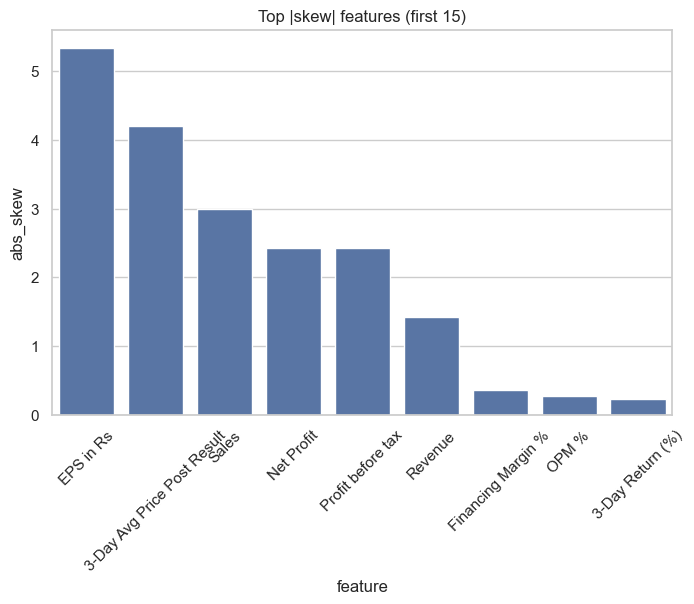

[saved] cell_11\bar_abs_skew_top15.png


In [55]:

CELL_DIR = Path("cell_11"); CELL_DIR.mkdir(exist_ok=True, parents=True)

def save_fig(fig, filename, dpi=160):
    path = CELL_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    print(f"[saved] {path}")

def save_table_image(df_table: pd.DataFrame, filename: str, title:str=None, max_rows=60, fontsize=9):
    fig, ax = plt.subplots(figsize=(min(12, max(6, df_table.shape[1]*0.9)), 
                                    min(18, max(2.5, min(max_rows, len(df_table))*0.35))))
    ax.axis("off")
    if title:
        ax.set_title(title, loc="left")
    tbl = ax.table(cellText=df_table.head(max_rows).values,
                   colLabels=df_table.columns, cellLoc="left", loc="upper left")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.scale(1, 1.3)
    save_fig(fig, filename)

COL_RET = "3-Day Return (%)"

# choose key numeric features that are widely populated
candidate_cols = [
    "EPS in Rs","OPM %","Net Profit","Profit before tax","Sales","Revenue",
    "Financing Margin %","3-Day Avg Price Post Result", COL_RET
]
num_cols_present = [c for c in candidate_cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]

rows = []
for c in num_cols_present:
    s = pd.to_numeric(df[c], errors="coerce").dropna()
    if len(s) < 20:
        continue
    skew = stats.skew(s, bias=False)
    kurt = stats.kurtosis(s, fisher=True, bias=False)  # 0 = normal
    strictly_pos = (s > 0).all()
    has_neg = (s < 0).any()

    # suggestion heuristic
    if strictly_pos and skew > 1.0:
        suggestion = "log1p"
    elif not strictly_pos and abs(skew) > 1.5:
        suggestion = "winsorize 1% tails"
    elif strictly_pos and 0.5 < skew <= 1.0:
        suggestion = "sqrt (optional)"
    else:
        suggestion = "none"

    rows.append([c, len(s), s.isna().sum(), float(skew), float(kurt), strictly_pos, has_neg, suggestion])

sk = pd.DataFrame(rows, columns=["feature","n","n_na","skew","kurtosis","strictly_positive","has_negative","suggested_transform"])
sk = sk.sort_values("skew", key=lambda x: x.abs(), ascending=False)

display(sk.style.format({"skew":"{:.3f}","kurtosis":"{:.3f}"}))
save_table_image(sk.round(3), "tbl_skewness_suggestions.png",
                 title="Skewness & suggested transforms")

# quick bar of absolute skew
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=sk.assign(abs_skew=sk["skew"].abs()).head(15), x="feature", y="abs_skew", ax=ax)
ax.set_title("Top |skew| features (first 15)")
ax.tick_params(axis="x", rotation=45)
plt.show()
save_fig(fig, "bar_abs_skew_top15.png")
